In [ ]:
!pip install pandas_ta yfinance feedparser -q
!pip install httpx beautifulsoup4 transformers torch
!pip install "numpy<2.0" --force-reinstall

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed

In [ ]:
import os
from google.colab import userdata
from openai import OpenAI
USER_MEMORY = {
    "default_user": {
        "risk_profile": "moderate",
        "history": []
    }
}

def get_user_profile(user_id="default_user"):
    return USER_MEMORY.get(user_id, USER_MEMORY["default_user"])

In [ ]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
client = OpenAI()

In [ ]:
from typing import TypedDict, Dict, Any, Optional

class State(TypedDict):
    query: str
    ticker: str

    task: str
    asset_type: str
    option_details: Dict[str, Any]
    user_profile: Dict[str, Any]

    market_data: Dict[str, Any]
    technical_signals: Dict[str, Any]
    options_data: Dict[str, Any]
    price_data: Any
    technical_full: Dict[str, Any]
    options_full: Dict[str, Any]

    news_sentiment: Dict[str, Any]
    llm_analysis: str

    risk_score: float
    weighted_signals: Dict[str, Any]

    reflection_count: int
    reflection_feedback: str
    data_retry_count: int
    combined_analysis: Dict[str, Any]
    data_quality: str

    option_context: Dict[str, Any]
    assignment_risk: str
    data_completeness: Dict[str, Any]

    decision: Dict[str, Any]

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
def get_market_data(ticker: str, period: str = "3mo") -> dict:
  """
    Fetch historical price data and compute basic statistics.

    Parameters:
        ticker: Stock symbol, e.g. "NVDA"
        period: Data time range, default "3mo" (3 months)

    Returns:
        dict with keys:
            - ticker: str
            - price_data: pd.DataFrame (OHLCV + derived columns)
  """
  try:
        df = yf.download(ticker, period=period, progress=False)
  except Exception as e:
        return {"error": f"Failed to download data for {ticker}: {str(e)}"}

  if df.empty:
        return {"error": f"No data returned for {ticker}"}

  if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)
  df['Daily_Return'] = df['Close'].pct_change()
  df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1
  df['Rolling_Volatility'] = df['Daily_Return'].rolling(window=20).std() * np.sqrt(252)
  df['Rolling_Max'] = df['Close'].cummax()
  df['Drawdown'] = (df['Close'] - df['Rolling_Max']) / df['Rolling_Max']

  returns_clean = df['Daily_Return'].dropna()
  current_price = float(df['Close'].iloc[-1])
  daily_vol = float(returns_clean.std())
  stats = {
        "current_price": current_price,
        "period_high": float(df['High'].max()),
        "period_low": float(df['Low'].min()),
        "total_return": float(df['Cumulative_Return'].iloc[-1]),
        "avg_daily_return": float(returns_clean.mean()),
        "daily_volatility": daily_vol,
        "annualized_volatility": float(daily_vol * np.sqrt(252)),
        "max_drawdown": float(df['Drawdown'].min()),
        "sharpe_ratio": float((returns_clean.mean() / daily_vol) * np.sqrt(252)) if daily_vol > 0 else 0.0,
        "sortino_ratio": _calculate_sortino(returns_clean),
        "var_95": float(returns_clean.quantile(0.05)),
        "cvar_95": float(returns_clean[returns_clean <= returns_clean.quantile(0.05)].mean()) if len(returns_clean[returns_clean <= returns_clean.quantile(0.05)]) > 0 else 0.0,  # 条件VaR
        "skewness": float(returns_clean.skew()),
        "kurtosis": float(returns_clean.kurtosis()),
        "avg_daily_volume": float(df['Volume'].mean()),
        "recent_5d_return": float(df['Close'].iloc[-1] / df['Close'].iloc[-6] - 1) if len(df) >= 6 else 0.0,
        "recent_20d_return": float(df['Close'].iloc[-1] / df['Close'].iloc[-21] - 1) if len(df) >= 21 else 0.0,
        "trading_days": len(df),
        "date_range": f"{df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}",
    }
  return {
      "ticker": ticker,
      "price_data": df,
      "stats": stats,
    }




In [ ]:
# technical analysis agent
def get_technical_indicators(df: pd.DataFrame) -> dict:
    """
    Compute a full suite of technical indicators and generate rule-based signals.

    Parameters:
        df: DataFrame with OHLCV columns (from get_market_data price_data)

    Returns:
        dict with keys:
            - indicators: dict of latest indicator values
            - signals: dict of rule-based signal interpretations
            - signal_summary: str overview of bullish/bearish count
            - rsi_thresholds: dict with the adaptive thresholds chosen and the
                              volatility regime that drove them
            - full_df: DataFrame with all indicator columns appended
    """
    df = df.copy()

    df['SMA_10'] = ta.sma(df['Close'], length=10)
    df['SMA_20'] = ta.sma(df['Close'], length=20)
    df['SMA_50'] = ta.sma(df['Close'], length=50)
    df['EMA_12'] = ta.ema(df['Close'], length=12)
    df['EMA_26'] = ta.ema(df['Close'], length=26)

    # RSI
    df['RSI'] = ta.rsi(df['Close'], length=14)

    # MACD
    macd_df = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['MACD'] = macd_df['MACD_12_26_9']
    df['MACD_Signal'] = macd_df['MACDs_12_26_9']
    df['MACD_Hist'] = macd_df['MACDh_12_26_9']

    bbands = ta.bbands(df['Close'], length=20, std=2)
    for col in bbands.columns:
        if 'BBL' in col:
            df['BB_Lower'] = bbands[col]
        elif 'BBM' in col:
            df['BB_Middle'] = bbands[col]
        elif 'BBU' in col:
            df['BB_Upper'] = bbands[col]
    df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Middle']

    stoch = ta.stoch(df['High'], df['Low'], df['Close'], k=14, d=3)
    df['Stoch_K'] = stoch['STOCHk_14_3_3']
    df['Stoch_D'] = stoch['STOCHd_14_3_3']

    adx_df = ta.adx(df['High'], df['Low'], df['Close'], length=14)
    df['ADX'] = adx_df['ADX_14']
    df['DI_Plus'] = adx_df['DMP_14']
    df['DI_Minus'] = adx_df['DMN_14']

    df['ATR'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)

    df['OBV'] = ta.obv(df['Close'], df['Volume'])

    df['Momentum'] = ta.mom(df['Close'], length=10)
    df['ROC'] = ta.roc(df['Close'], length=10)

    latest = df.iloc[-1]
    prev = df.iloc[-2]
    current_price = float(latest['Close'])

    indicators = {
        "current_price": current_price,
        "sma_10": float(latest['SMA_10']) if pd.notna(latest['SMA_10']) else None,
        "sma_20": float(latest['SMA_20']) if pd.notna(latest['SMA_20']) else None,
        "sma_50": float(latest['SMA_50']) if pd.notna(latest['SMA_50']) else None,
        "ema_12": float(latest['EMA_12']) if pd.notna(latest['EMA_12']) else None,
        "ema_26": float(latest['EMA_26']) if pd.notna(latest['EMA_26']) else None,
        "rsi": float(latest['RSI']) if pd.notna(latest['RSI']) else None,
        "macd": float(latest['MACD']) if pd.notna(latest['MACD']) else None,
        "macd_signal": float(latest['MACD_Signal']) if pd.notna(latest['MACD_Signal']) else None,
        "macd_histogram": float(latest['MACD_Hist']) if pd.notna(latest['MACD_Hist']) else None,
        "stoch_k": float(latest['Stoch_K']) if pd.notna(latest['Stoch_K']) else None,
        "stoch_d": float(latest['Stoch_D']) if pd.notna(latest['Stoch_D']) else None,
        "bb_upper": float(latest['BB_Upper']) if pd.notna(latest['BB_Upper']) else None,
        "bb_middle": float(latest['BB_Middle']) if pd.notna(latest['BB_Middle']) else None,
        "bb_lower": float(latest['BB_Lower']) if pd.notna(latest['BB_Lower']) else None,
        "bb_width": float(latest['BB_Width']) if pd.notna(latest['BB_Width']) else None,
        "atr": float(latest['ATR']) if pd.notna(latest['ATR']) else None,
        "adx": float(latest['ADX']) if pd.notna(latest['ADX']) else None,
        "di_plus": float(latest['DI_Plus']) if pd.notna(latest['DI_Plus']) else None,
        "di_minus": float(latest['DI_Minus']) if pd.notna(latest['DI_Minus']) else None,
        "momentum": float(latest['Momentum']) if pd.notna(latest['Momentum']) else None,
        "roc": float(latest['ROC']) if pd.notna(latest['ROC']) else None,
    }

    # rule-based signal interpretation
    signals = {}
    bullish_count = 0
    bearish_count = 0

    # --- Adaptive RSI thresholds based on realized annualized volatility ---
    daily_returns = df['Close'].pct_change().dropna()
    annualized_vol = float(daily_returns.std() * np.sqrt(252)) if not daily_returns.empty else 0.0

    if annualized_vol < 0.30:
        rsi_oversold, rsi_overbought = 30, 70
        vol_regime = "low_vol"
    elif annualized_vol < 0.50:
        rsi_oversold, rsi_overbought = 25, 75
        vol_regime = "high_vol"
    else:
        rsi_oversold, rsi_overbought = 20, 80
        vol_regime = "extreme_vol"

    # RSI signal (with adaptive thresholds, indentation bug fixed)
    if indicators["rsi"] is not None:
        if indicators["rsi"] < rsi_oversold:
            signals["rsi"] = {
                "signal": "oversold",
                "direction": "bullish",
                "detail": (
                    f"RSI={indicators['rsi']:.1f}, below {rsi_oversold} "
                    f"({vol_regime}, ann. vol={annualized_vol:.0%}) "
                    f"-> oversold, potential bounce"
                )
            }
            bullish_count += 1
        elif indicators["rsi"] > rsi_overbought:
            signals["rsi"] = {
                "signal": "overbought",
                "direction": "bearish",
                "detail": (
                    f"RSI={indicators['rsi']:.1f}, above {rsi_overbought} "
                    f"({vol_regime}, ann. vol={annualized_vol:.0%}) "
                    f"-> overbought, potential pullback"
                )
            }
            bearish_count += 1
        else:
            signals["rsi"] = {
                "signal": "neutral",
                "direction": "neutral",
                "detail": (
                    f"RSI={indicators['rsi']:.1f}, in neutral zone "
                    f"({rsi_oversold}-{rsi_overbought}, {vol_regime})"
                )
            }

    # MACD signal
    if indicators["macd"] is not None and indicators["macd_signal"] is not None:
        prev_macd_cross = float(prev['MACD'] - prev['MACD_Signal']) if pd.notna(prev['MACD']) else None

        if indicators["macd"] > indicators["macd_signal"]:
            direction = "bullish"
            bullish_count += 1
            if prev_macd_cross is not None and prev_macd_cross < 0:
                detail = "MACD just crossed ABOVE signal line -> fresh bullish crossover"
            else:
                detail = f"MACD({indicators['macd']:.2f}) > Signal({indicators['macd_signal']:.2f}) -> bullish"
        else:
            direction = "bearish"
            bearish_count += 1
            if prev_macd_cross is not None and prev_macd_cross > 0:
                detail = "MACD just crossed BELOW signal line -> fresh bearish crossover"
            else:
                detail = f"MACD({indicators['macd']:.2f}) < Signal({indicators['macd_signal']:.2f}) -> bearish"
        signals["macd"] = {
            "signal": "bullish_cross" if direction == "bullish" else "bearish_cross",
            "direction": direction,
            "detail": detail,
        }

    # Moving average alignment
    if all(indicators[k] is not None for k in ["sma_20", "sma_50"]):
        if current_price > indicators["sma_20"] > indicators["sma_50"]:
            signals["moving_averages"] = {
                "signal": "bullish_alignment", "direction": "bullish",
                "detail": f"Price(${current_price:.2f}) > SMA20(${indicators['sma_20']:.2f}) > SMA50(${indicators['sma_50']:.2f})"
            }
            bullish_count += 1
        elif current_price < indicators["sma_20"] < indicators["sma_50"]:
            signals["moving_averages"] = {
                "signal": "bearish_alignment", "direction": "bearish",
                "detail": f"Price(${current_price:.2f}) < SMA20(${indicators['sma_20']:.2f}) < SMA50(${indicators['sma_50']:.2f})"
            }
            bearish_count += 1
        else:
            signals["moving_averages"] = {
                "signal": "mixed", "direction": "neutral",
                "detail": f"Mixed: Price=${current_price:.2f}, SMA20=${indicators['sma_20']:.2f}, SMA50=${indicators['sma_50']:.2f}"
            }

    # Bollinger Bands
    if indicators["bb_upper"] is not None and indicators["bb_lower"] is not None:
        if current_price > indicators["bb_upper"]:
            signals["bollinger"] = {
                "signal": "above_upper", "direction": "bearish",
                "detail": f"Price above upper band (${indicators['bb_upper']:.2f}) -> potential reversal down"
            }
            bearish_count += 1
        elif current_price < indicators["bb_lower"]:
            signals["bollinger"] = {
                "signal": "below_lower", "direction": "bullish",
                "detail": f"Price below lower band (${indicators['bb_lower']:.2f}) -> potential reversal up"
            }
            bullish_count += 1
        else:
            bb_position = (current_price - indicators["bb_lower"]) / (indicators["bb_upper"] - indicators["bb_lower"])
            signals["bollinger"] = {
                "signal": "within_bands", "direction": "neutral",
                "detail": f"Price within bands, position: {bb_position:.0%} (0%=lower, 100%=upper)"
            }

    # Stochastic
    if indicators["stoch_k"] is not None:
        if indicators["stoch_k"] > 80:
            signals["stochastic"] = {
                "signal": "overbought", "direction": "bearish",
                "detail": f"%K={indicators['stoch_k']:.1f}, above 80 -> overbought"
            }
            bearish_count += 1
        elif indicators["stoch_k"] < 20:
            signals["stochastic"] = {
                "signal": "oversold", "direction": "bullish",
                "detail": f"%K={indicators['stoch_k']:.1f}, below 20 -> oversold"
            }
            bullish_count += 1
        else:
            signals["stochastic"] = {
                "signal": "neutral", "direction": "neutral",
                "detail": f"%K={indicators['stoch_k']:.1f}, in neutral zone"
            }

    # ADX
    if indicators["adx"] is not None:
        trend_strength = "strong" if indicators["adx"] > 25 else "weak"
        trend_dir = "up" if (indicators.get("di_plus") or 0) > (indicators.get("di_minus") or 0) else "down"
        signals["adx"] = {
            "signal": f"{trend_strength}_trend_{trend_dir}",
            "direction": "bullish" if trend_dir == "up" and trend_strength == "strong"
                         else "bearish" if trend_dir == "down" and trend_strength == "strong"
                         else "neutral",
            "detail": (
                f"ADX={indicators['adx']:.1f} "
                f"({'strong trend' if trend_strength == 'strong' else 'weak/no trend'}), "
                f"+DI={indicators.get('di_plus', 0):.1f}, "
                f"-DI={indicators.get('di_minus', 0):.1f} -> trend direction: {trend_dir}"
            )
        }
        if trend_strength == "strong":
            if trend_dir == "up":
                bullish_count += 1
            else:
                bearish_count += 1

    # Volume-price divergence
    vp_div = _detect_volume_price_divergence(df)
    if vp_div["detected"]:
        signals["volume_divergence"] = {
            "signal": vp_div["type"],
            "direction": vp_div["direction"],
            "detail": vp_div["detail"]
        }
        if vp_div["direction"] == "bullish":
            bullish_count += 1
        elif vp_div["direction"] == "bearish":
            bearish_count += 1

    # OBV trend
    if 'OBV' in df.columns and len(df) >= 20:
        obv_sma = df['OBV'].rolling(20).mean()
        if pd.notna(obv_sma.iloc[-1]):
            obv_current = float(df['OBV'].iloc[-1])
            obv_avg = float(obv_sma.iloc[-1])
            if obv_current > obv_avg * 1.05:
                signals["obv"] = {
                    "signal": "obv_rising", "direction": "bullish",
                    "detail": "OBV above 20-day average -> buying pressure increasing"
                }
                bullish_count += 1
            elif obv_current < obv_avg * 0.95:
                signals["obv"] = {
                    "signal": "obv_falling", "direction": "bearish",
                    "detail": "OBV below 20-day average -> selling pressure increasing"
                }
                bearish_count += 1
            else:
                signals["obv"] = {
                    "signal": "obv_flat", "direction": "neutral",
                    "detail": "OBV near 20-day average -> no clear volume trend"
                }

    # signal stats
    signal_stats = {}
    if 'RSI' in df.columns:
        signal_stats["rsi_overbought_days"] = int((df['RSI'] > rsi_overbought).sum())
        signal_stats["rsi_oversold_days"] = int((df['RSI'] < rsi_oversold).sum())

    if 'MACD' in df.columns and 'MACD_Signal' in df.columns:
        macd_diff = df['MACD'] - df['MACD_Signal']
        signal_stats["macd_golden_crosses"] = int(((macd_diff > 0) & (macd_diff.shift(1) < 0)).sum())
        signal_stats["macd_death_crosses"] = int(((macd_diff < 0) & (macd_diff.shift(1) > 0)).sum())

    if 'BB_Upper' in df.columns and 'BB_Lower' in df.columns:
        signal_stats["bb_above_upper_days"] = int((df['Close'] > df['BB_Upper']).sum())
        signal_stats["bb_below_lower_days"] = int((df['Close'] < df['BB_Lower']).sum())

    # summary
    total = bullish_count + bearish_count
    bullish_pct = bullish_count / total * 100 if total > 0 else 50

    signal_summary = (
        f"Technical signals: {bullish_count} bullish, {bearish_count} bearish, "
        f"{len(signals) - bullish_count - bearish_count} neutral. "
        f"Overall lean: "
        f"{'BULLISH' if bullish_count > bearish_count else 'BEARISH' if bearish_count > bullish_count else 'NEUTRAL'} "
        f"({bullish_pct:.0f}% bullish). "
        f"RSI thresholds used: {rsi_oversold}/{rsi_overbought} ({vol_regime})."
    )

    return {
        "indicators": indicators,
        "signals": signals,
        "signal_stats": signal_stats,
        "signal_summary": signal_summary,
        "bullish_count": bullish_count,
        "bearish_count": bearish_count,
        "rsi_thresholds": {
            "oversold": rsi_oversold,
            "overbought": rsi_overbought,
            "regime": vol_regime,
            "annualized_vol": round(annualized_vol, 4),
        },
        "full_df": df,
    }

In [ ]:
# option chain agent
def get_options_data(ticker: str, num_expirations: int = 3) -> dict:
    """
    Fetch options chain data and compute derived metrics.

    Parameters:
        ticker: Stock symbol
        num_expirations: Number of nearest expiration dates to fetch, default 3

    Returns:
        dict with keys:
            - ticker: str
            - current_price: float
            - expirations: list of expiration dates used
            - put_call_ratio: float
            - max_pain: float (nearest expiration)
            - max_call_oi_strike: float (resistance level)
            - max_put_oi_strike: float (support level)
            - atm_iv: float (at-the-money implied volatility)
            - iv_skew: float (OTM put IV - ATM IV)
            - iv_term_structure: dict (near-term vs far-term IV)
            - call_total_oi: int
            - put_total_oi: int
            - chains: dict of raw chain DataFrames
    """
    try:
        stock = yf.Ticker(ticker)
        current_price = stock.info.get('currentPrice') or stock.info.get('regularMarketPrice')

        # Fallback: get price from historical data
        if current_price is None:
            hist = stock.history(period="1d")
            if not hist.empty:
                current_price = float(hist['Close'].iloc[-1])
            else:
                return {"error": f"Cannot get current price for {ticker}"}

        current_price = float(current_price)
    except Exception as e:
        return {"error": f"Failed to get ticker info: {str(e)}"}

    # Fetch options chains
    try:
        available_exps = stock.options
    except Exception as e:
        return {"error": f"No options data available for {ticker}: {str(e)}"}

    if not available_exps:
        return {"error": f"No options expirations found for {ticker}"}

    expirations = list(available_exps[:num_expirations])

    all_calls = []
    all_puts = []
    chains = {}

    for exp in expirations:
        try:
            chain = stock.option_chain(exp)
            calls = chain.calls.copy()
            puts = chain.puts.copy()

            # Add expiration column
            calls['expiration'] = exp
            puts['expiration'] = exp

            # Clean: remove rows where openInterest is NaN or 0
            calls = calls[calls['openInterest'].notna() & (calls['openInterest'] > 0)]
            puts = puts[puts['openInterest'].notna() & (puts['openInterest'] > 0)]

            all_calls.append(calls)
            all_puts.append(puts)
            chains[exp] = {"calls": chain.calls, "puts": chain.puts}  # Keep raw data
        except Exception as e:
            print(f"Warning: failed to get chain for {exp}: {e}")
            continue

    if not all_calls or not all_puts:
        return {"error": "Failed to retrieve any valid options data"}

    calls_df = pd.concat(all_calls, ignore_index=True)
    puts_df = pd.concat(all_puts, ignore_index=True)

    # Put/Call Ratio
    call_total_oi = int(calls_df['openInterest'].sum())
    put_total_oi = int(puts_df['openInterest'].sum())
    put_call_ratio = round(put_total_oi / call_total_oi, 4) if call_total_oi > 0 else None

    # Max Pain (nearest expiration)
    nearest_exp = expirations[0]
    nearest_calls = calls_df[calls_df['expiration'] == nearest_exp]
    nearest_puts = puts_df[puts_df['expiration'] == nearest_exp]
    max_pain = _calculate_max_pain(nearest_calls, nearest_puts, current_price)

    # Max OI Strike (support/resistance levels)
    max_call_oi_strike = None
    max_put_oi_strike = None

    if not nearest_calls.empty:
        max_call_oi_idx = nearest_calls['openInterest'].idxmax()
        max_call_oi_strike = float(nearest_calls.loc[max_call_oi_idx, 'strike'])

    if not nearest_puts.empty:
        max_put_oi_idx = nearest_puts['openInterest'].idxmax()
        max_put_oi_strike = float(nearest_puts.loc[max_put_oi_idx, 'strike'])

    # ATM Implied Volatility
    atm_iv = _get_atm_iv(nearest_calls, nearest_puts, current_price)

    # IV Skew
    iv_skew = _calculate_iv_skew(nearest_puts, current_price, atm_iv)

    # IV Term Structure (near-term vs far-term)
    iv_term_structure = _calculate_iv_term_structure(calls_df, puts_df, expirations, current_price)

    # Signal interpretation
    options_signals = {}

    if put_call_ratio is not None:
        if put_call_ratio > 1.2:
            options_signals["put_call_ratio"] = {
                "signal": "high_put_call", "direction": "bearish",
                "detail": f"P/C Ratio={put_call_ratio:.2f} (>1.2) -> heavy put buying, market is fearful"
            }
        elif put_call_ratio < 0.7:
            options_signals["put_call_ratio"] = {
                "signal": "low_put_call", "direction": "bullish",
                "detail": f"P/C Ratio={put_call_ratio:.2f} (<0.7) -> heavy call buying, market is optimistic"
            }
        else:
            options_signals["put_call_ratio"] = {
                "signal": "neutral_put_call", "direction": "neutral",
                "detail": f"P/C Ratio={put_call_ratio:.2f} -> balanced sentiment"
            }

    if max_pain is not None:
        pain_diff_pct = (max_pain - current_price) / current_price * 100
        if pain_diff_pct > 3:
            options_signals["max_pain"] = {
                "signal": "max_pain_above", "direction": "bullish",
                "detail": f"Max Pain=${max_pain:.2f} is {pain_diff_pct:.1f}% above current price -> potential upward pull"
            }
        elif pain_diff_pct < -3:
            options_signals["max_pain"] = {
                "signal": "max_pain_below", "direction": "bearish",
                "detail": f"Max Pain=${max_pain:.2f} is {abs(pain_diff_pct):.1f}% below current price -> potential downward pull"
            }
        else:
            options_signals["max_pain"] = {
                "signal": "max_pain_near", "direction": "neutral",
                "detail": f"Max Pain=${max_pain:.2f} is near current price (${current_price:.2f}) -> price likely pinned"
            }

    if iv_skew is not None:
        if iv_skew > 0.1:
            options_signals["iv_skew"] = {
                "signal": "high_skew", "direction": "bearish",
                "detail": f"IV Skew={iv_skew:.3f} -> elevated demand for downside protection"
            }
        else:
            options_signals["iv_skew"] = {
                "signal": "normal_skew", "direction": "neutral",
                "detail": f"IV Skew={iv_skew:.3f} -> normal skew levels"
            }

    return {
        "ticker": ticker,
        "current_price": current_price,
        "expirations": expirations,
        # Core metrics
        "put_call_ratio": put_call_ratio,
        "max_pain": max_pain,
        "max_call_oi_strike": max_call_oi_strike,  # Resistance level
        "max_put_oi_strike": max_put_oi_strike,      # Support level
        "atm_iv": atm_iv,
        "iv_skew": iv_skew,
        "iv_term_structure": iv_term_structure,
        # Total open interest
        "call_total_oi": call_total_oi,
        "put_total_oi": put_total_oi,
        # Signals
        "options_signals": options_signals,
        # Raw data (for debug or further analysis)
        "chains": chains,
    }

In [ ]:
# options helper functions
def _calculate_max_pain(calls: pd.DataFrame, puts: pd.DataFrame, current_price: float) -> float:
    """
    Calculate Max Pain: the strike price that minimizes total option holders' intrinsic value.
    For each possible expiration price (strike), compute total intrinsic value of all contracts,
    and find the strike that minimizes this total.
    """
    if calls.empty and puts.empty:
        return None

    # Collect all strikes
    all_strikes = sorted(set(
        list(calls['strike'].unique()) + list(puts['strike'].unique())
    ))

    if not all_strikes:
        return None

    min_pain = float('inf')
    max_pain_strike = all_strikes[0]

    for test_price in all_strikes:
        total_pain = 0

        # Call intrinsic value: max(test_price - strike, 0) * openInterest
        if not calls.empty:
            call_pain = calls.apply(
                lambda row: max(test_price - row['strike'], 0) * row['openInterest'],
                axis=1
            ).sum()
            total_pain += call_pain

        # Put intrinsic value: max(strike - test_price, 0) * openInterest
        if not puts.empty:
            put_pain = puts.apply(
                lambda row: max(row['strike'] - test_price, 0) * row['openInterest'],
                axis=1
            ).sum()
            total_pain += put_pain

        if total_pain < min_pain:
            min_pain = total_pain
            max_pain_strike = test_price

    return float(max_pain_strike)


def _get_atm_iv(calls: pd.DataFrame, puts: pd.DataFrame, current_price: float) -> float:
    """Get implied volatility of the strike nearest to current price (average of call and put)."""
    atm_iv = None

    try:
        if not calls.empty:
            calls_valid = calls[calls['impliedVolatility'].notna() & (calls['impliedVolatility'] > 0)]
            if not calls_valid.empty:
                atm_call_idx = (calls_valid['strike'] - current_price).abs().idxmin()
                atm_call_iv = float(calls_valid.loc[atm_call_idx, 'impliedVolatility'])
            else:
                atm_call_iv = None
        else:
            atm_call_iv = None

        if not puts.empty:
            puts_valid = puts[puts['impliedVolatility'].notna() & (puts['impliedVolatility'] > 0)]
            if not puts_valid.empty:
                atm_put_idx = (puts_valid['strike'] - current_price).abs().idxmin()
                atm_put_iv = float(puts_valid.loc[atm_put_idx, 'impliedVolatility'])
            else:
                atm_put_iv = None
        else:
            atm_put_iv = None

        # Average of available IVs
        ivs = [v for v in [atm_call_iv, atm_put_iv] if v is not None]
        if ivs:
            atm_iv = round(sum(ivs) / len(ivs), 6)

    except Exception:
        pass

    return atm_iv


def _calculate_iv_skew(puts: pd.DataFrame, current_price: float, atm_iv: float) -> float:
    """
    Calculate IV Skew: difference between average OTM put IV and ATM IV.
    OTM puts = puts with strike below current price.
    Skew > 0 indicates higher demand for downside protection.
    """
    if atm_iv is None or puts.empty:
        return None

    try:
        otm_puts = puts[
            (puts['strike'] < current_price * 0.95) &  # At least 5% OTM
            (puts['impliedVolatility'].notna()) &
            (puts['impliedVolatility'] > 0)
        ]

        if otm_puts.empty:
            return None

        avg_otm_iv = float(otm_puts['impliedVolatility'].mean())
        return round(avg_otm_iv - atm_iv, 6)

    except Exception:
        return None


def _calculate_iv_term_structure(
    calls_df: pd.DataFrame, puts_df: pd.DataFrame,
    expirations: list, current_price: float
) -> dict:
    """
    Calculate IV term structure: compare ATM IV across expirations.
    If near-term IV > far-term IV (backwardation), short-term uncertainty is elevated.
    """
    if len(expirations) < 2:
        return {"available": False}

    term_ivs = {}

    for exp in expirations:
        exp_calls = calls_df[calls_df['expiration'] == exp]
        exp_puts = puts_df[puts_df['expiration'] == exp]
        iv = _get_atm_iv(exp_calls, exp_puts, current_price)
        if iv is not None:
            term_ivs[exp] = iv

    if len(term_ivs) < 2:
        return {"available": False}

    sorted_exps = sorted(term_ivs.keys())
    near_iv = term_ivs[sorted_exps[0]]
    far_iv = term_ivs[sorted_exps[-1]]

    return {
        "available": True,
        "by_expiration": term_ivs,
        "near_term_iv": near_iv,
        "far_term_iv": far_iv,
        "structure": "backwardation" if near_iv > far_iv else "contango",
        "detail": f"Near({sorted_exps[0]}) IV={near_iv:.3f}, Far({sorted_exps[-1]}) IV={far_iv:.3f} -> "
                  f"{'short-term uncertainty is higher' if near_iv > far_iv else 'normal term structure'}"
    }

In [ ]:
# weighted composite score - time decay weighted scoring
def get_weighted_signals(tech_result: dict, options_result: dict = None,
                         recent_days: int = 5) -> dict:
    """
    Apply time-decay weighting to all signals and compute a composite score.

    Inspired by the layered memory mechanism in the FinMem paper:
    - Signals from the most recent N days get 2x weight (short-term memory)
    - Older signals get 1x weight (long-term memory)
    - Different signal categories have different base weights (technical vs options)

    Parameters:
        tech_result: Return value from get_technical_indicators()
        options_result: Return value from get_options_data() (optional)
        recent_days: Number of days in the recency window, default 5

    Returns:
        dict with keys:
            - composite_score: float (-100 to 100, positive=bullish, negative=bearish)
            - confidence: float (0-1, higher when signals agree)
            - recent_momentum: str ("accelerating_bullish"/"decelerating"/...)
            - signal_agreement: float (signal consistency percentage)
            - score_breakdown: dict (sub-scores by category)
            - recommendation_strength: str ("strong"/"moderate"/"weak")
    """
    df = tech_result.get("full_df")
    if df is None or df.empty:
        return {"error": "No data available for weighted scoring"}

    # 1. Time-decay weighted technical signals
    recent = df.tail(recent_days)
    older = df.iloc[:-recent_days] if len(df) > recent_days else pd.DataFrame()

    tech_score = 0.0

    # RSI with time decay
    if 'RSI' in df.columns:
        recent_rsi = recent['RSI'].dropna()
        older_rsi = older['RSI'].dropna() if not older.empty else pd.Series(dtype=float)

        # Recent oversold days (weight 2x) + older oversold days (weight 1x)
        recent_oversold = (recent_rsi < 30).sum() * 2
        recent_overbought = (recent_rsi > 70).sum() * 2
        older_oversold = (older_rsi < 30).sum() * 1 if not older_rsi.empty else 0
        older_overbought = (older_rsi > 70).sum() * 1 if not older_rsi.empty else 0

        tech_score += (recent_oversold + older_oversold) * 5
        tech_score -= (recent_overbought + older_overbought) * 5

    # MACD with time decay: recent crossovers have higher weight
    if 'MACD' in df.columns and 'MACD_Signal' in df.columns:
        recent_macd_diff = (recent['MACD'] - recent['MACD_Signal']).dropna()
        if not recent_macd_diff.empty:
            recent_golden = ((recent_macd_diff > 0) & (recent_macd_diff.shift(1) < 0)).sum()
            recent_death = ((recent_macd_diff < 0) & (recent_macd_diff.shift(1) > 0)).sum()
            tech_score += recent_golden * 15  # Recent golden cross gets high weight
            tech_score -= recent_death * 15

        # Current MACD direction
        if not recent_macd_diff.empty and recent_macd_diff.iloc[-1] > 0:
            tech_score += 5
        elif not recent_macd_diff.empty:
            tech_score -= 5

    # Moving average position
    indicators = tech_result.get("indicators", {})
    price = indicators.get("current_price", 0)
    sma20 = indicators.get("sma_20")
    sma50 = indicators.get("sma_50")
    if price and sma20 and sma50:
        if price > sma20 > sma50:
            tech_score += 10
        elif price < sma20 < sma50:
            tech_score -= 10

    # Bollinger Bands position
    bb_lower = indicators.get("bb_lower")
    bb_upper = indicators.get("bb_upper")
    if price and bb_lower and bb_upper:
        if price < bb_lower:
            tech_score += 8  # Oversold bounce
        elif price > bb_upper:
            tech_score -= 8  # Overbought pullback

    # ADX trend strength bonus
    adx = indicators.get("adx")
    di_plus = indicators.get("di_plus", 0)
    di_minus = indicators.get("di_minus", 0)
    if adx and adx > 25:
        trend_bonus = 5
        if di_plus > di_minus:
            tech_score += trend_bonus
        else:
            tech_score -= trend_bonus

    # 2. Options signal weighting
    options_score = 0.0
    if options_result and "error" not in options_result:
        pcr = options_result.get("put_call_ratio")
        if pcr is not None:
            if pcr > 1.2:
                options_score -= 10  # Market fear -> bearish
            elif pcr < 0.7:
                options_score += 10  # Market optimism -> bullish
            # Contrarian logic: extreme fear may signal a bottom
            if pcr > 1.5:
                options_score += 5  # Extreme fear -> contrarian bullish

        max_pain = options_result.get("max_pain")
        curr_price = options_result.get("current_price")
        if max_pain and curr_price:
            pain_pct = (max_pain - curr_price) / curr_price * 100
            if pain_pct > 3:
                options_score += 8
            elif pain_pct < -3:
                options_score -= 8

        iv_skew = options_result.get("iv_skew")
        if iv_skew is not None and iv_skew > 0.1:
            options_score -= 5  # High skew -> fear of downside

    # 3. Recent momentum assessment
    recent_momentum = "neutral"
    if 'RSI' in df.columns and len(recent) >= 2:
        rsi_now = recent['RSI'].iloc[-1] if pd.notna(recent['RSI'].iloc[-1]) else None
        rsi_prev = recent['RSI'].iloc[0] if pd.notna(recent['RSI'].iloc[0]) else None
        if rsi_now is not None and rsi_prev is not None:
            rsi_change = rsi_now - rsi_prev
            if rsi_change > 5 and rsi_now > 50:
                recent_momentum = "accelerating_bullish"
            elif rsi_change > 5 and rsi_now <= 50:
                recent_momentum = "recovering"
            elif rsi_change < -5 and rsi_now < 50:
                recent_momentum = "accelerating_bearish"
            elif rsi_change < -5 and rsi_now >= 50:
                recent_momentum = "weakening"
            else:
                recent_momentum = "steady"

    # 4. Composite score
    # Technical weight 60%, options weight 40%
    composite = tech_score * 0.6 + options_score * 0.4
    # Clamp to [-100, 100]
    composite = max(-100, min(100, composite))

    # 5. Signal agreement (confidence)
    all_signals = tech_result.get("signals", {})
    directions = [s["direction"] for s in all_signals.values() if s["direction"] != "neutral"]
    if options_result and "error" not in options_result:
        opt_sigs = options_result.get("options_signals", {})
        directions += [s["direction"] for s in opt_sigs.values() if s["direction"] != "neutral"]

    if directions:
        bullish_ratio = directions.count("bullish") / len(directions)
        bearish_ratio = directions.count("bearish") / len(directions)
        agreement = max(bullish_ratio, bearish_ratio)
    else:
        agreement = 0.5

    confidence = round(agreement, 3)

    abs_score = abs(composite)
    if abs_score > 40 and confidence > 0.6:
        strength = "strong"
    elif abs_score > 20:
        strength = "moderate"
    else:
        strength = "weak"

    return {
        "composite_score": round(composite, 2),
        "confidence": confidence,
        "recent_momentum": recent_momentum,
        "signal_agreement": round(agreement * 100, 1),
        "score_breakdown": {
            "technical_score": round(tech_score, 2),
            "options_score": round(options_score, 2),
            "tech_weight": 0.6,
            "options_weight": 0.4,
        },
        "recommendation_strength": strength,
        "direction": "bullish" if composite > 10 else "bearish" if composite < -10 else "neutral",
    }


In [ ]:
def get_support_resistance(df: pd.DataFrame, options_result: dict = None,
                           window: int = 20) -> dict:
    """
    Compute support and resistance levels from multiple data sources.

    Sources:
    1. Technical: recent highs/lows, moving averages, Bollinger Bands
    2. Options: max pain, highest OI strikes
    3. Volume clusters (simplified Volume Profile)

    Parameters:
        df: DataFrame with OHLCV and technical indicator columns
        options_result: Return value from get_options_data() (optional)
        window: Lookback window in trading days

    Returns:
        dict with keys:
            - support_levels: list of (price, source, strength) tuples
            - resistance_levels: list of (price, source, strength) tuples
            - key_support: float (strongest support level)
            - key_resistance: float (strongest resistance level)
    """
    current_price = float(df['Close'].iloc[-1])
    supports = []
    resistances = []

    recent = df.tail(window)
    recent_high = float(recent['High'].max())
    recent_low = float(recent['Low'].min())

    if recent_low < current_price:
        supports.append({"price": recent_low, "source": "recent_low", "strength": 2})
    if recent_high > current_price:
        resistances.append({"price": recent_high, "source": "recent_high", "strength": 2})

    for col, name in [('SMA_20', 'SMA20'), ('SMA_50', 'SMA50'), ('EMA_12', 'EMA12')]:
        if col in df.columns and pd.notna(df[col].iloc[-1]):
            ma_val = float(df[col].iloc[-1])
            if ma_val < current_price:
                supports.append({"price": ma_val, "source": name, "strength": 2 if 'SMA_50' == col else 1})
            elif ma_val > current_price:
                resistances.append({"price": ma_val, "source": name, "strength": 2 if 'SMA_50' == col else 1})


    if 'BB_Lower' in df.columns and pd.notna(df['BB_Lower'].iloc[-1]):
        bb_lower = float(df['BB_Lower'].iloc[-1])
        bb_upper = float(df['BB_Upper'].iloc[-1])
        supports.append({"price": bb_lower, "source": "BB_lower", "strength": 1})
        resistances.append({"price": bb_upper, "source": "BB_upper", "strength": 1})

    if len(recent) >= 10:
        price_bins = pd.cut(recent['Close'], bins=10)
        vol_by_price = recent.groupby(price_bins, observed=True)['Volume'].sum()
        if not vol_by_price.empty:
            top_vol_bin = vol_by_price.idxmax()
            vol_center = (top_vol_bin.left + top_vol_bin.right) / 2
            if vol_center < current_price:
                supports.append({"price": round(float(vol_center), 2),
                                "source": "volume_cluster", "strength": 3})
            elif vol_center > current_price:
                resistances.append({"price": round(float(vol_center), 2),
                                   "source": "volume_cluster", "strength": 3})


    if options_result and "error" not in options_result:
        max_pain = options_result.get("max_pain")
        if max_pain:
            if max_pain < current_price:
                supports.append({"price": max_pain, "source": "max_pain", "strength": 3})
            elif max_pain > current_price:
                resistances.append({"price": max_pain, "source": "max_pain", "strength": 3})

        put_strike = options_result.get("max_put_oi_strike")
        if put_strike and put_strike < current_price:
            supports.append({"price": put_strike, "source": "put_wall", "strength": 3})

        call_strike = options_result.get("max_call_oi_strike")
        if call_strike and call_strike > current_price:
            resistances.append({"price": call_strike, "source": "call_wall", "strength": 3})

    supports = _merge_nearby_levels(supports, threshold_pct=0.01)
    resistances = _merge_nearby_levels(resistances, threshold_pct=0.01)

    supports.sort(key=lambda x: x["strength"], reverse=True)
    resistances.sort(key=lambda x: x["strength"], reverse=True)

    return {
        "current_price": current_price,
        "support_levels": supports,
        "resistance_levels": resistances,
        "key_support": supports[0]["price"] if supports else None,
        "key_resistance": resistances[0]["price"] if resistances else None,
    }


def _merge_nearby_levels(levels: list, threshold_pct: float = 0.01) -> list:
    """Merge support/resistance levels that are within +/-threshold_pct of each other."""
    if not levels:
        return []

    sorted_levels = sorted(levels, key=lambda x: x["price"])
    merged = [sorted_levels[0].copy()]

    for level in sorted_levels[1:]:
        if abs(level["price"] - merged[-1]["price"]) / merged[-1]["price"] < threshold_pct:
            total_strength = merged[-1]["strength"] + level["strength"]
            merged[-1]["price"] = (
                merged[-1]["price"] * merged[-1]["strength"] +
                level["price"] * level["strength"]
            ) / total_strength
            merged[-1]["price"] = round(merged[-1]["price"], 2)
            merged[-1]["strength"] = total_strength
            merged[-1]["source"] = f"{merged[-1]['source']}+{level['source']}"
        else:
            merged.append(level.copy())

    return merged


In [ ]:
def _calculate_sortino(returns: pd.Series) -> float:
    """Calculate Sortino Ratio: only penalizes downside volatility (more suitable than Sharpe for risk)."""
    downside = returns[returns < 0]
    if downside.empty or downside.std() == 0:
        return 0.0
    return float((returns.mean() / downside.std()) * np.sqrt(252))


def _detect_volume_price_divergence(df: pd.DataFrame, lookback: int = 10) -> dict:
    """
    Detect volume-price divergence:
    - Bearish divergence: price makes new high but volume declines (upward momentum fading)
    - Bullish divergence: price makes new low but volume declines (selling exhaustion)
    """
    if len(df) < lookback + 5:
        return {"detected": False}

    recent = df.tail(lookback)
    prev = df.iloc[-(lookback * 2):-lookback]

    if prev.empty:
        return {"detected": False}

    recent_high = recent['Close'].max()
    prev_high = prev['Close'].max()
    recent_avg_vol = recent['Volume'].mean()
    prev_avg_vol = prev['Volume'].mean()

    recent_low = recent['Close'].min()
    prev_low = prev['Close'].min()

    if recent_high > prev_high and recent_avg_vol < prev_avg_vol * 0.85:
        return {
            "detected": True,
            "type": "bearish_divergence",
            "direction": "bearish",
            "detail": f"Price made new high (${recent_high:.2f} > ${prev_high:.2f}) "
                      f"but volume declined ({recent_avg_vol/1e6:.1f}M vs {prev_avg_vol/1e6:.1f}M) -> bearish divergence"
        }

    if recent_low < prev_low and recent_avg_vol < prev_avg_vol * 0.85:
        return {
            "detected": True,
            "type": "bullish_divergence",
            "direction": "bullish",
            "detail": f"Price made new low (${recent_low:.2f} < ${prev_low:.2f}) "
                      f"but volume declined ({recent_avg_vol/1e6:.1f}M vs {prev_avg_vol/1e6:.1f}M) -> selling exhaustion"
        }

    return {"detected": False}

In [ ]:
def planner(state: State) -> State:
    query = state.get("query", "")
    user_id = state.get("user_id", "default_user")

    state["user_profile"] = get_user_profile(user_id)

    try:
        prompt = f"""
You are a trading assistant.

Extract structured information from the query.

Query:
"{query}"

Return JSON:
{{
  "ticker": "stock ticker if mentioned, else null",
  "task": one of [
    "buy_stock",
    "sell_stock",
    "buy_option",
    "sell_option",
    "hold_option",
    "close_option",
    "roll_option",
    "option_management",
    "general"
  ],
  "asset_type": one of ["stock", "option", "both", "unknown"],
  "option_details": {{
    "strike": <number or null>,
    "expiration": "<date or null>",
    "position": "long_call" or "long_put" or "short_call" or "short_put" or null
  }}
}}

Classification hints:
- If the query asks whether to hold, close, buy back, or roll an existing
  option position, classify task as "option_management" or "roll_option".
- If the query is about opening a new option trade, use "buy_option" or "sell_option".
- If the query is about a stock purchase or sale, use "buy_stock" or "sell_stock".
"""
        response = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[{"role": "user", "content": prompt}],
            response_format={"type": "json_object"},
            temperature=0
        )
        result = json.loads(response.choices[0].message.content)

    except Exception:
        result = {"ticker": None, "task": "general",
                  "asset_type": "unknown", "option_details": {}}

    ticker = result.get("ticker")
    if ticker:
        state["ticker"] = ticker.upper()

    state["task"] = result.get("task", "general")
    state["asset_type"] = result.get("asset_type", "unknown")
    state["option_details"] = result.get("option_details", {})

    # Default placeholders
    state.setdefault("market_data", {})
    state.setdefault("technical_signals", {})
    state.setdefault("options_data", {})
    state.setdefault("price_data", None)
    state.setdefault("technical_full", {})
    state.setdefault("options_full", {})
    state.setdefault("news_sentiment", {})
    state.setdefault("risk_score", 0.0)
    state.setdefault("weighted_signals", {})
    state.setdefault("llm_analysis", "")
    state.setdefault("decision", {})
    state.setdefault("reflection_count", 0)
    state.setdefault("reflection_feedback", "")
    state.setdefault("data_retry_count", 0)

    return state

In [ ]:
# ============================================================
# Rule-based option Greeks-lite helpers and data quality scoring
# - compute_dte: days to expiration
# - compute_option_position_context: moneyness from strike vs current price
# - estimate_assignment_risk: rule-based assignment risk for short calls/puts
# - compute_data_completeness: penalty when options data is missing
# ============================================================

from datetime import datetime


def compute_dte(expiration):
    """Days to expiration. Accepts 'YYYY-MM-DD' or natural-language dates."""
    if not expiration:
        return None
    formats = ["%Y-%m-%d", "%B %d, %Y", "%b %d, %Y", "%m/%d/%Y", "%Y/%m/%d"]
    for fmt in formats:
        try:
            exp = datetime.strptime(str(expiration).strip(), fmt)
            return max((exp - datetime.now()).days, 0)
        except Exception:
            continue
    return None


def compute_option_position_context(state):
    """
    Compute moneyness context from current price, strike, and position.
    Returns {} if data is missing.
    """
    market = state.get("market_data", {}) or {}
    details = state.get("option_details", {}) or {}

    price = market.get("current_price")
    strike = details.get("strike")
    position = details.get("position")
    expiration = details.get("expiration")

    if price is None or strike is None or strike == 0:
        return {}

    try:
        price = float(price)
        strike = float(strike)
    except (TypeError, ValueError):
        return {}

    moneyness_pct = (price - strike) / strike

    # Position-aware moneyness label
    if abs(moneyness_pct) < 0.02:
        moneyness = "ATM"
    elif position in ("long_call", "short_call"):
        moneyness = "ITM" if price > strike else "OTM"
    elif position in ("long_put", "short_put"):
        moneyness = "ITM" if price < strike else "OTM"
    else:
        moneyness = "ITM for calls / OTM for puts" if price > strike else "OTM for calls / ITM for puts"

    dte = compute_dte(expiration)

    return {
        "underlying_price": round(price, 2),
        "strike": round(strike, 2),
        "moneyness_pct": round(moneyness_pct, 4),
        "moneyness": moneyness,
        "position": position,
        "dte": dte,
    }


def estimate_assignment_risk(position, moneyness_pct, dte):
    """
    Rule-based assignment risk for short option positions.
    For long positions, assignment risk does not apply.
    """
    if position not in ("short_call", "short_put"):
        return "N/A"
    if moneyness_pct is None or dte is None:
        return "unknown"

    # For short calls: positive moneyness_pct = ITM (bad)
    # For short puts: negative moneyness_pct = ITM (bad)
    itm_metric = moneyness_pct if position == "short_call" else -moneyness_pct

    if itm_metric > 0.05 and dte <= 7:
        return "high"
    if itm_metric > 0 and dte <= 14:
        return "moderate"
    if itm_metric > 0:
        return "low_to_moderate"
    return "low"


def compute_data_completeness(state):
    """
    Score 0.0 to 1.0 based on which expected data fields are present.
    Lower score = more missing data = decision agent should reduce confidence.
    """
    required = ["market_data", "technical_signals", "news_sentiment"]
    optional_for_options = ["implied_volatility", "iv_skew", "max_pain", "put_call_ratio"]

    score = 1.0
    missing = []

    for key in required:
        val = state.get(key)
        if not val:
            score -= 0.2
            missing.append(key)

    if state.get("asset_type") in ("option", "both"):
        options = state.get("options_data", {}) or {}
        for k in optional_for_options:
            v = options.get(k)
            if v in (None, "N/A", "unavailable", ""):
                score -= 0.1
                missing.append(f"options.{k}")

    return {
        "score": max(0.0, round(score, 2)),
        "missing_fields": missing,
    }


In [ ]:
def decision_agent(state: State) -> State:
    quant = state.get("weighted_signals", {})
    risk = state.get("risk_score", 0.5)
    news = state.get("news_sentiment", {})
    tech = state.get("technical_signals", {})
    options = state.get("options_data", {})
    user = state.get("user_profile", {})
    market = state.get("market_data", {})
    asset_type = state.get("asset_type", "unknown")
    option_details = state.get("option_details", {})
    combined = state.get("combined_analysis", {})

    # Check if this is a revision
    feedback = state.get("reflection_feedback", "")
    revision_note = ""
    if feedback:
        revision_note = f"""
IMPORTANT: Your previous recommendation was rejected.
Feedback: {feedback}
Please revise your recommendation to address this feedback.
"""

    # ---------- NEW: Rule-based option context (moneyness, DTE, assignment risk) ----------
    option_context = {}
    assignment_risk = "N/A"
    if asset_type in ("option", "both"):
        option_context = compute_option_position_context(state)
        if option_context:
            assignment_risk = estimate_assignment_risk(
                position=option_context.get("position"),
                moneyness_pct=option_context.get("moneyness_pct"),
                dte=option_context.get("dte"),
            )
    state["option_context"] = option_context
    state["assignment_risk"] = assignment_risk

    # ---------- NEW: Data completeness ----------
    data_completeness = compute_data_completeness(state)
    state["data_completeness"] = data_completeness

    completeness_note = f"""
=== DATA COMPLETENESS ===
Score: {data_completeness['score']} (1.0 = complete, 0.0 = mostly missing)
Missing fields: {data_completeness['missing_fields'] if data_completeness['missing_fields'] else 'none'}
If score is below 0.7 you MUST lower the confidence value and explicitly mention
which fields were unavailable in your reasoning.
"""

    # ---------- Common data section ----------
    common_data = f"""
User risk profile: {user.get("risk_profile", "moderate")}

=== MARKET DATA ===
Current price: {market.get("current_price", "N/A")}
Date range: {market.get("date_range", "N/A")}
Last trading date: {market.get("last_trading_date", "N/A")}
Recent 5-day return: {market.get("recent_5d_return", "N/A")}
Recent 20-day return: {market.get("recent_20d_return", "N/A")}
Volatility: {market.get("volatility", "N/A")}
Sharpe ratio: {market.get("sharpe", "N/A")}
Max drawdown: {market.get("drawdown", "N/A")}

=== TECHNICAL INDICATORS ===
Current price from technical data: {tech.get("current_price", "N/A")}
SMA 20: {tech.get("sma_20", "N/A")}
SMA 50: {tech.get("sma_50", "N/A")}
RSI: {tech.get("rsi", "N/A")}
MACD: {tech.get("macd", "N/A")}
MACD signal: {tech.get("macd_signal", "N/A")}
ADX: {tech.get("adx", "N/A")}
Bullish signals: {tech.get("bullish_count", 0)} | Bearish: {tech.get("bearish_count", 0)}
RSI thresholds (adaptive): oversold<{tech.get("rsi_thresholds", {}).get("oversold", "N/A")}, overbought>{tech.get("rsi_thresholds", {}).get("overbought", "N/A")} ({tech.get("rsi_thresholds", {}).get("regime", "N/A")}, ann. vol={tech.get("rsi_thresholds", {}).get("annualized_vol", "N/A")})
Summary: {tech.get("summary", "N/A")}

=== NEWS SENTIMENT ===
Score: {news.get("score", "N/A")} (range: -1 to 1)
Summary: {news.get("summary", "N/A")}
Key events: {news.get("key_events", [])}
Content coverage: {news.get("content_coverage", "N/A")} (ratio of articles with full content, 0-1)

=== RISK AND COMBINED SIGNALS ===
Risk score: {risk} (0=low, 1=high)
Composite quant score: {quant.get("composite_score", "N/A")}
Quant confidence: {quant.get("confidence", "N/A")}
Recent momentum: {quant.get("recent_momentum", "N/A")}
Signal agreement: {quant.get("signal_agreement", "N/A")}
Recommendation strength: {quant.get("recommendation_strength", "N/A")}
Weighted direction: {quant.get("direction", "N/A")}

Combined score: {combined.get("combined_score", "N/A")} (range: -1 to 1)
Pre-action: {combined.get("pre_action", "N/A")}
Weights used: quant={combined.get("weights", {}).get("quant")}, news={combined.get("weights", {}).get("news")}
Signal conflict: {combined.get("conflict_detected", False)}
{completeness_note}
NOTE:
The pre-action is computed from quantitative rules.
You may adjust it, but you MUST explain the exact reason if your final action differs.

IMPORTANT REASONING STYLE:
Do NOT write the final reason as a list of indicators.
Use the data to form a trading thesis.
Your reasoning should explain:
1. The main reason for the action.
2. The strongest evidence supporting the action.
3. The strongest evidence against the action.
4. The execution plan or next step.

User question:
{state.get("query")}

{revision_note}
"""

    # ---------- Stock-specific prompt ----------
    if asset_type == "stock":
        prompt = f"""You are a professional stock trading assistant.
The user is asking about STOCK trading, not options.

{common_data}

=== STOCK-SPECIFIC FOCUS ===
- Price context: Use current price and last trading date.
- Price trend: Is the stock showing actionable momentum or just mixed signals?
- Momentum: What do RSI and MACD imply?
- Trend strength: Does ADX confirm the move or show weak trend?
- Risk: Are volatility, drawdown, Sharpe ratio, and recent returns acceptable?
- News: Is news sentiment strong enough to support the trade?

INSTRUCTIONS:
1. Do NOT simply list every indicator.
2. Give a synthesized trading thesis.
3. Explain the main driver of the action.
4. Explain the strongest evidence against the action.
5. Use specific numbers only when they support the thesis.
6. If final action differs from pre-action, explain exactly why.
7. Give an execution plan: enter now, wait for pullback, position size, stop loss, or invalidation condition.
8. Adjust for the user risk profile.
9. If date and price are available, mention the data date and current price in the reason.

Return JSON:
{{
  "action": "BUY" or "SELL" or "HOLD",
  "thesis": "one-sentence main trading thesis",
  "reason": "synthesized reasoning, not a list of indicators",
  "key_drivers": ["main driver 1", "main driver 2", "main driver 3"],
  "conflicting_signals": ["opposing evidence or risk 1", "opposing evidence or risk 2"],
  "confidence": <float 0.0 to 1.0>,
  "entry_plan": "specific execution plan",
  "stop_loss": "suggested stop loss or N/A",
  "risk_warning": "key risks"
}}
"""

    # ---------- Option-specific prompt ----------
    elif asset_type == "option":
        # NEW: build a structured option-context block
        if option_context:
            option_context_block = f"""
=== RULE-BASED OPTION CONTEXT (computed from option chain) ===
Underlying price: {option_context.get('underlying_price', 'N/A')}
Strike: {option_context.get('strike', 'N/A')}
Moneyness: {option_context.get('moneyness', 'N/A')} ({option_context.get('moneyness_pct', 'N/A'):+.2%} from strike)
Days to expiration (DTE): {option_context.get('dte', 'N/A')}
Position: {option_context.get('position', 'N/A')}
Assignment risk (rule-based): {assignment_risk}
"""
        else:
            option_context_block = """
=== RULE-BASED OPTION CONTEXT ===
Insufficient data to compute moneyness or DTE.
"""

        prompt = f"""You are a professional options trading assistant.
The user is asking about OPTIONS trading.

{common_data}

=== OPTIONS MARKET DATA ===
Put/Call ratio: {options.get("put_call_ratio", "N/A")}
Implied volatility (ATM): {options.get("implied_volatility", "N/A")}
IV skew: {options.get("iv_skew", "N/A")}
Max pain: {options.get("max_pain", "N/A")}
Data quality: {options.get("data_quality", "N/A")}
Missing fields: {options.get("missing_fields", [])}

=== USER'S POSITION ===
Strike: {option_details.get("strike", "N/A")}
Expiration: {option_details.get("expiration", "N/A")}
Position: {option_details.get("position", "N/A")}
{option_context_block}
=== OPTIONS-SPECIFIC FOCUS ===
- Trade structure: long call, short call, covered call, put, roll, or close.
- Moneyness (use the rule-based value above, not your own estimate).
- IV and skew: Is the option expensive, or is downside protection demand elevated?
- Time decay: Use the DTE value above directly.
- Assignment risk: Use the rule-based value above; do not contradict it.
- Max pain and put/call ratio: What do options-market signals imply?
- Technical indicators and news: Use them as supporting evidence, not the whole decision.

INSTRUCTIONS:
1. Do NOT simply list every indicator.
2. Focus on the option trade structure first.
3. Cite the moneyness, DTE, and assignment risk values explicitly in your reasoning.
4. Technical indicators and news are supporting evidence.
5. For existing short call or covered call positions, explicitly compare HOLD vs BUY BACK/CLOSE vs ROLL.
6. Explain why the rejected actions are worse than the selected action.
7. If final action differs from pre-action, explain exactly why.
8. Give a concrete execution plan and risk warning.
9. If options data is partial or unavailable, lower confidence and say so.
10. If date and price are available, mention the data date and current price in the reason.

Return JSON:
{{
  "action": "BUY" or "SELL" or "HOLD" or "ROLL" or "AVOID",
  "thesis": "one-sentence main option thesis",
  "reason": "synthesized reasoning focused on option risk/reward",
  "key_drivers": ["main driver 1", "main driver 2", "main driver 3"],
  "alternatives_considered": {{
    "hold": "why holding is good or bad",
    "close": "why closing is good or bad",
    "roll": "why rolling is good or bad"
  }},
  "confidence": <float 0.0 to 1.0>,
  "execution_plan": "specific next step",
  "theta_warning": "time decay assessment",
  "risk_warning": "key risks"
}}
"""

    # ---------- Both / unknown → full analysis ----------
    else:
        prompt = f"""You are a professional trading assistant.

{common_data}

=== OPTIONS MARKET DATA ===
Put/Call ratio: {options.get("put_call_ratio", "N/A")}
Implied volatility: {options.get("implied_volatility", "N/A")}
IV skew: {options.get("iv_skew", "N/A")}
Max pain: {options.get("max_pain", "N/A")}

INSTRUCTIONS:
1. Do NOT simply list every indicator.
2. Form a trading thesis from the available market, technical, options, news, and risk data.
3. Explain the main driver of the action.
4. Explain the strongest evidence against the action.
5. When signals conflict, explain the conflict and justify your weighting.
6. If final action differs from pre-action, explain exactly why.
7. Give a concrete next step.
8. Adjust for user risk profile.
9. If date and price are available, mention the data date and current price in the reason.

Return JSON:
{{
  "action": "BUY" or "SELL" or "HOLD" or "ROLL" or "AVOID",
  "thesis": "one-sentence main trading thesis",
  "reason": "synthesized reasoning, not a list of indicators",
  "key_drivers": ["main driver 1", "main driver 2", "main driver 3"],
  "conflicting_signals": ["opposing evidence or risk 1", "opposing evidence or risk 2"],
  "confidence": <float 0.0 to 1.0>,
  "execution_plan": "specific next step",
  "risk_warning": "key risks"
}}
"""

    try:
        response = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[{"role": "user", "content": prompt}],
            response_format={"type": "json_object"},
            temperature=0
        )
        result = json.loads(response.choices[0].message.content)

    except Exception as e:
        result = {
            "action": "HOLD",
            "thesis": "Decision generation failed.",
            "reason": f"Decision failed: {str(e)}",
            "key_drivers": [],
            "conflicting_signals": [],
            "confidence": 0.0,
            "execution_plan": "N/A",
            "risk_warning": "System error"
        }

    state["decision"] = result
    state["llm_analysis"] = json.dumps(result, indent=2)

    return state

In [ ]:
import json
import feedparser
import yfinance as yf
import urllib.parse
import httpx
from bs4 import BeautifulSoup
from transformers import pipeline


# ============================================================
# News Sentiment Agent
# - Google News RSS first
# - yfinance news fallback
# - Use RSS summary / article content when available
# - Use headline fallback when content is unavailable
# - FinBERT produces sentiment score
# - LLM only summarizes key events
# ============================================================


# ---------- FinBERT setup ----------
# Load FinBERT once globally.
# top_k=None returns all labels in newer transformers versions.
try:
    finbert = pipeline(
        "text-classification",
        model="ProsusAI/finbert",
        top_k=None
    )
    FINBERT_AVAILABLE = True
    FINBERT_ERROR = None
except Exception as e:
    finbert = None
    FINBERT_AVAILABLE = False
    FINBERT_ERROR = str(e)
    print("FinBERT failed to load. Will use LLM fallback for sentiment score.")
    print(FINBERT_ERROR)


PAYWALLED_DOMAINS = [
    "wsj.com",
    "ft.com",
    "bloomberg.com",
    "barrons.com",
    "marketwatch.com"
]


def is_paywalled(url: str) -> bool:
    """
    Check whether the URL appears to be from a commonly paywalled source.
    """
    if not url:
        return False
    return any(domain in url.lower() for domain in PAYWALLED_DOMAINS)


def fetch_article_content(url: str, timeout: int = 5, max_chars: int = 1500) -> str:
    """
    Try to fetch article body text.

    If the content is unavailable, blocked, too short, or extraction fails,
    return an empty string.
    """
    try:
        headers = {
            "User-Agent": (
                "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/120.0.0.0 Safari/537.36"
            )
        }

        resp = httpx.get(
            url,
            timeout=timeout,
            headers=headers,
            follow_redirects=True
        )

        if resp.status_code != 200:
            return ""

        soup = BeautifulSoup(resp.text, "html.parser")

        # Remove noisy page elements
        for tag in soup(["script", "style", "nav", "footer", "aside", "header"]):
            tag.decompose()

        article = soup.find("article") or soup.find("main")

        if article:
            text = article.get_text(separator=" ", strip=True)
        else:
            paragraphs = soup.find_all("p")
            text = " ".join(
                p.get_text(separator=" ", strip=True)
                for p in paragraphs
            )

        text = " ".join(text.split())

        if len(text) < 200:
            return ""

        return text[:max_chars]

    except Exception as e:
        print(f"Article extraction failed for {url}: {e}")
        return ""


def finbert_score(texts: list) -> float:
    """
    Score a list of article texts or headlines using FinBERT.

    Output range:
    - positive close to +1
    - negative close to -1
    - neutral close to 0

    Formula:
    score = P(positive) - P(negative)

    This function is written to handle different transformers return formats:
    1. [[{"label": "...", "score": ...}, ...]]
    2. [{"label": "...", "score": ...}, ...]
    3. {"label": "...", "score": ...}
    """
    if not texts:
        return 0.0

    if not FINBERT_AVAILABLE:
        return None

    scores = []

    for text in texts:
        if not text or not isinstance(text, str):
            continue

        try:
            raw = finbert(text[:512])

            # Case 1 or 2: list output
            if isinstance(raw, list) and len(raw) > 0:
                result = raw[0]

                # Case 1: raw = [[{...}, {...}, {...}]]
                if isinstance(result, list):
                    label_scores = result

                # Case 2: raw = [{...}, {...}, {...}]
                elif isinstance(result, dict):
                    label_scores = raw

                else:
                    print("Unexpected FinBERT nested output:", raw)
                    continue

            # Case 3: dict output
            elif isinstance(raw, dict):
                label_scores = [raw]

            else:
                print("Unexpected FinBERT output:", raw)
                continue

            score_map = {
                item["label"].lower(): item["score"]
                for item in label_scores
                if isinstance(item, dict)
                and "label" in item
                and "score" in item
            }

            positive = score_map.get("positive", 0.0)
            negative = score_map.get("negative", 0.0)

            net_score = positive - negative
            scores.append(net_score)

        except Exception as e:
            print(f"FinBERT failed on one text: {e}")
            continue

    if not scores:
        return 0.0

    return round(sum(scores) / len(scores), 3)


def news_agent(state: State) -> State:
    """
    News Sentiment Agent.

    Steps:
    1. Fetch recent news from Google News RSS.
    2. If Google News fails, fallback to yfinance news.
    3. Use RSS summary or article content when available.
    4. If unavailable, fallback to title only.
    5. Use FinBERT for sentiment scoring when available.
    6. Use LLM only for summary and key events.
    """
    ticker = state.get("ticker", "UNKNOWN")

    if ticker == "UNKNOWN" or ticker == "":
        state["news_sentiment"] = {
            "score": 0.0,
            "summary": "No ticker provided, cannot fetch news.",
            "headlines": [],
            "key_events": [],
            "content_coverage": 0.0,
            "score_method": "No ticker",
            "articles_used": 0,
            "full_text_articles": 0,
        }
        return state

    articles = []

    # ------------------------------------------------------------
    # 1. Try Google News RSS
    # ------------------------------------------------------------
    try:
        query = urllib.parse.quote(f"{ticker} stock")
        rss_url = (
            f"https://news.google.com/rss/search?q={query}"
            f"&hl=en-US&gl=US&ceid=US:en"
        )

        feed = feedparser.parse(rss_url)

        if hasattr(feed, "entries") and len(feed.entries) > 0:
            for entry in feed.entries[:8]:
                title = entry.get("title", "")
                url = entry.get("link", "")
                published = entry.get("published", "")

                article = {
                    "title": title,
                    "url": url,
                    "published": published,
                    "content": "",
                    "content_source": "none"
                }

                # Google News RSS often includes summary snippets.
                rss_summary = entry.get("summary", "")
                if rss_summary:
                    soup = BeautifulSoup(rss_summary, "html.parser")
                    summary_text = soup.get_text(separator=" ", strip=True)
                    if len(summary_text) >= 50:
                        article["content"] = summary_text[:1500]
                        article["content_source"] = "rss_summary"

                # If RSS summary is unavailable, try article extraction.
                if (
                    not article["content"]
                    and article["url"]
                    and not is_paywalled(article["url"])
                ):
                    extracted_text = fetch_article_content(article["url"])
                    if extracted_text:
                        article["content"] = extracted_text
                        article["content_source"] = "article_extraction"

                articles.append(article)

    except Exception as e:
        print(f"Google News RSS failed: {e}")

    # ------------------------------------------------------------
    # 2. Fallback: yfinance news
    # ------------------------------------------------------------
    if not articles:
        try:
            stock = yf.Ticker(ticker)
            yf_news = stock.news

            for item in yf_news[:8]:
                title = item.get("title", "")
                url = item.get("link", "") or item.get("url", "")
                published = item.get("providerPublishTime", "")

                article = {
                    "title": title,
                    "url": url,
                    "published": published,
                    "content": "",
                    "content_source": "none"
                }

                if url and not is_paywalled(url):
                    extracted_text = fetch_article_content(url)
                    if extracted_text:
                        article["content"] = extracted_text
                        article["content_source"] = "article_extraction"

                articles.append(article)

        except Exception as e:
            print(f"yfinance news failed: {e}")

    # ------------------------------------------------------------
    # 3. If no articles found, return neutral
    # ------------------------------------------------------------
    if not articles:
        state["news_sentiment"] = {
            "score": 0.0,
            "summary": f"No recent news found for {ticker}. News source may be unavailable.",
            "headlines": [],
            "key_events": [],
            "content_coverage": 0.0,
            "score_method": "No news found",
            "articles_used": 0,
            "full_text_articles": 0,
        }
        return state

    # ------------------------------------------------------------
    # 4. Build FinBERT and LLM inputs
    # ------------------------------------------------------------
    headlines_only = []
    news_input = ""
    finbert_inputs = []

    for i, art in enumerate(articles):
        title = art.get("title", "")
        content = art.get("content", "")
        source = art.get("content_source", "none")

        headlines_only.append(title)

        # FinBERT uses content when available; otherwise headline fallback.
        if content:
            finbert_inputs.append(content[:512])
        else:
            finbert_inputs.append(title[:512])

        news_input += f"\n[Article {i + 1}]\n"
        news_input += f"Title: {title}\n"

        if content:
            news_input += f"Content source: {source}\n"
            news_input += f"Content excerpt: {content[:800]}\n"
        else:
            news_input += "Content source: title_only_fallback\n"
            news_input += "Content: unavailable; using title only.\n"

    content_coverage = round(
        sum(1 for art in articles if art.get("content")) / len(articles),
        3
    )

    full_text_articles = sum(
        1 for art in articles
        if art.get("content_source") == "article_extraction"
    )

    # ------------------------------------------------------------
    # 5. FinBERT sentiment scoring
    # ------------------------------------------------------------
    score = finbert_score(finbert_inputs)
    use_llm_score_fallback = score is None

    # ------------------------------------------------------------
    # 6. LLM summary, and sentiment fallback only if needed
    # ------------------------------------------------------------
    if use_llm_score_fallback:
        prompt = f"""
Analyze these financial news articles for {ticker}.

FinBERT was unavailable, so you should provide:
1. A sentiment score from -1.0 bearish to 1.0 bullish
2. A 3-4 sentence summary of the key fundamental events
3. The most important discrete events

Content coverage: {content_coverage}

News:
{news_input}

Return JSON:
{{
    "score": <float from -1.0 bearish to 1.0 bullish>,
    "summary": "<3-4 sentence summary focusing on key fundamental events>",
    "key_events": ["most important event 1", "most important event 2"]
}}
"""
    else:
        prompt = f"""
Analyze these financial news articles for {ticker}.

Your job is NOT to score sentiment.
FinBERT already produced the numerical sentiment score.

FinBERT sentiment score: {score}
Content coverage: {content_coverage}

Your job is to:
1. Summarize the key fundamental events in 3-4 sentences
2. Extract the most important discrete events
3. Mention whether the evidence is mostly based on RSS summaries, extracted article text, or title-only fallback.

News:
{news_input}

Return JSON:
{{
    "summary": "<3-4 sentence summary focusing on key fundamental events>",
    "key_events": ["most important event 1", "most important event 2"]
}}
"""

    try:
        response = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[{"role": "user", "content": prompt}],
            response_format={"type": "json_object"},
            temperature=0
        )

        result = json.loads(response.choices[0].message.content)

        if use_llm_score_fallback:
            score = float(result.get("score", 0.0))

        summary = result.get("summary", "")
        key_events = result.get("key_events", [])

    except Exception as e:
        if use_llm_score_fallback:
            score = 0.0

        summary = f"News summary failed: {str(e)}"
        key_events = []

    # ------------------------------------------------------------
    # 7. Save output into shared state
    # ------------------------------------------------------------
    state["news_sentiment"] = {
        "score": round(float(score), 3),
        "summary": summary,
        "headlines": headlines_only,
        "key_events": key_events,
        "content_coverage": content_coverage,
        "score_method": (
            "FinBERT on RSS/article content with headline fallback"
            if not use_llm_score_fallback
            else "LLM fallback because FinBERT unavailable"
        ),
        "articles_used": len(articles),
        "full_text_articles": full_text_articles,
        "content_sources": {
            "rss_summary": sum(
                1 for art in articles
                if art.get("content_source") == "rss_summary"
            ),
            "article_extraction": sum(
                1 for art in articles
                if art.get("content_source") == "article_extraction"
            ),
            "title_only": sum(
                1 for art in articles
                if not art.get("content")
            ),
        },
        "article_sources": [
            {
                "title": art.get("title", ""),
                "url": art.get("url", ""),
                "content_source": art.get("content_source", "none")
            }
            for art in articles
        ]
    }

    return state

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
test_state = {
    "ticker": "NVDA",
    "query": "Should I buy NVDA stock right now?"
}

test_state = news_agent(test_state)

print("Score:", test_state["news_sentiment"]["score"])
print("Score method:", test_state["news_sentiment"]["score_method"])
print("Content coverage:", test_state["news_sentiment"]["content_coverage"])
print("Articles used:", test_state["news_sentiment"]["articles_used"])
print("Full text articles:", test_state["news_sentiment"]["full_text_articles"])
print("Content sources:", test_state["news_sentiment"]["content_sources"])
print("Summary:", test_state["news_sentiment"]["summary"])
print("Key events:", test_state["news_sentiment"]["key_events"])
print("First 3 headlines:", test_state["news_sentiment"]["headlines"][:3])

Score: 0.192
Score method: FinBERT on RSS/article content with headline fallback
Content coverage: 0.75
Articles used: 8
Full text articles: 0
Content sources: {'rss_summary': 6, 'article_extraction': 0, 'title_only': 2}
Summary: Nvidia is approaching a critical earnings report that has attracted significant market attention, with some analysts suggesting the stock appears undervalued ahead of the announcement. The company continues to benefit from its expanding role in the AI sector, driving its stock toward record highs. Institutional investors, such as Ring Mountain Capital LLC, have increased their holdings in Nvidia, signaling confidence in its growth prospects. Additionally, Nvidia is involved in new AI infrastructure deals, further solidifying its position in the AI hardware market.
Key events: ['Upcoming high-stakes Nvidia earnings report expected to impact stock valuation', "Nvidia's stock heading toward record highs driven by AI expansion", 'Ring Mountain Capital LLC increase

In [ ]:
def market_agent(state: State) -> State:
    result = get_market_data(state["ticker"])

    if "error" in result:
        state["market_data"] = {}
        return state

    stats = result["stats"]

    state["market_data"] = {
    "current_price": stats.get("current_price"),
    "date_range": stats.get("date_range"),
    "last_trading_date": result["price_data"].index[-1].strftime("%Y-%m-%d"),
    "volatility": stats.get("annualized_volatility"),
    "returns": stats.get("avg_daily_return"),
    "drawdown": stats.get("max_drawdown"),
    "sharpe": stats.get("sharpe_ratio"),
    }

    state["price_data"] = result.get("price_data")

    return state

In [ ]:
def technical_agent(state: State) -> State:
    df = state.get("price_data")

    if df is None:
        state["technical_signals"] = {}
        return state

    result = get_technical_indicators(df)
    indicators = result.get("indicators", {})

    state["technical_signals"] = {
        "current_price": indicators.get("current_price"),
        "sma_20": indicators.get("sma_20"),
        "sma_50": indicators.get("sma_50"),
        "rsi": indicators.get("rsi"),
        "macd": indicators.get("macd"),
        "macd_signal": indicators.get("macd_signal"),
        "adx": indicators.get("adx"),
        "bullish_count": result.get("bullish_count", 0),
        "bearish_count": result.get("bearish_count", 0),
        "rsi_thresholds": result.get("rsi_thresholds", {}),
        "summary": result.get("signal_summary"),
    }

    state["technical_full"] = result

    return state

In [ ]:
def options_agent(state: State) -> State:
    result = get_options_data(state["ticker"])

    if "error" in result:
        state["options_data"] = {
            "implied_volatility": "unavailable",
            "put_call_ratio": "unavailable",
            "iv_skew": "unavailable",
            "max_pain": "unavailable",
            "data_quality": "unavailable",
            "missing_fields": ["implied_volatility", "put_call_ratio", "iv_skew", "max_pain"],
        }
        return state

    # Pull each field; track which ones are missing for transparency
    raw = {
        "implied_volatility": result.get("atm_iv"),
        "put_call_ratio": result.get("put_call_ratio"),
        "iv_skew": result.get("iv_skew"),
        "max_pain": result.get("max_pain"),
    }
    missing_fields = [k for k, v in raw.items() if v in (None, "")]

    # Replace nulls with "unavailable" so the LLM does not silently ignore them
    cleaned = {k: (v if v not in (None, "") else "unavailable") for k, v in raw.items()}

    if not missing_fields:
        data_quality = "complete"
    elif len(missing_fields) < len(raw):
        data_quality = "partial"
    else:
        data_quality = "unavailable"

    cleaned["data_quality"] = data_quality
    cleaned["missing_fields"] = missing_fields

    state["options_data"] = cleaned
    state["options_full"] = result
    return state

In [ ]:
def risk_agent(state: State) -> State:
    tech = state.get("technical_full")
    options = state.get("options_full")

    if not tech:
        state["risk_score"] = 0.5
        return state

    weighted = get_weighted_signals(tech, options)

    composite = weighted.get("composite_score", 0)

    risk_score = 1 - (composite + 100) / 200

    state["risk_score"] = round(float(risk_score), 3)
    state["weighted_signals"] = weighted

    return state

In [ ]:
def combine_signals(quant_score, news_score, risk):
    conflict = (quant_score * news_score < 0)

    if risk > 0.7:
        wq, wn = 0.8, 0.2
    elif abs(news_score) > 0.4:
        wq, wn = 0.5, 0.5
    else:
        wq, wn = 0.6, 0.4

    combined = wq * quant_score + wn * news_score
    if conflict:
        combined *= 0.7

    return combined, conflict

In [ ]:
def signal_combiner(state: State) -> State:
    """
    Explicitly combine signals with defined weights BEFORE
    passing to LLM. LLM's job is to explain and adjust,
    not to decide from scratch.
    """
    quant = state.get("weighted_signals", {})
    news = state.get("news_sentiment", {})
    risk = state.get("risk_score", 0.5)
    asset_type = state.get("asset_type", "unknown")

    quant_score = quant.get("composite_score", 0) / 100  # normalize to [-1, 1]
    news_score = news.get("score", 0)

    # --- Dynamic weighting based on asset type ---
    if asset_type == "option":
        # Options: quant signals (which include IV, P/C ratio)
        # matter more than news
        wq, wn = 0.75, 0.25
    elif risk > 0.7:
        # High risk environment: trust quant more than news
        wq, wn = 0.8, 0.2
    elif abs(news_score) > 0.4:
        # Strong news signal: give it more weight
        wq, wn = 0.5, 0.5
    else:
        # Default
        wq, wn = 0.6, 0.4

    combined = wq * quant_score + wn * news_score

    # Detect conflict (quant says buy but news says sell, or vice versa)
    conflict = (quant_score * news_score < 0) and \
               (abs(quant_score) > 0.1 and abs(news_score) > 0.1)

    # Reduce confidence if signals conflict
    if conflict:
        combined *= 0.7

    # Map to action
    if combined > 0.15:
        pre_action = "BUY"
    elif combined < -0.15:
        pre_action = "SELL"
    else:
        pre_action = "HOLD"

    # Store the quantitative conclusion
    state["combined_analysis"] = {
        "combined_score": round(combined, 3),
        "pre_action": pre_action,
        "weights": {"quant": wq, "news": wn},
        "conflict_detected": conflict,
        "quant_score": round(quant_score, 3),
        "news_score": round(news_score, 3),
    }

    return state

In [ ]:
def route_by_asset_type(state: State) -> str:
    """
    After technical analysis, route based on asset type:
    - stock: skip options chain, go to news
    - option/both: must run options chain
    """
    asset_type = state.get("asset_type", "unknown")
    if asset_type == "stock":
        return "skip_options"
    return "run_options"

In [ ]:
def reflection_agent(state: State) -> State:
    """
    Reviews the decision agent's output for quality and consistency.
    If the decision is poor, provides feedback for revision.
    Inspired by FinCon's self-critiquing mechanism.
    """
    decision = state.get("decision", {})
    tech = state.get("technical_signals", {})
    news = state.get("news_sentiment", {})
    quant = state.get("weighted_signals", {})
    options = state.get("options_data", {})

    prompt = f"""You are a senior risk manager reviewing a trading recommendation.

=== DECISION UNDER REVIEW ===
Action: {decision.get("action", "N/A")}
Reason: {decision.get("reason", "N/A")}
Confidence: {decision.get("confidence", "N/A")}

=== AVAILABLE DATA ===
Technical summary: {tech.get("summary", "N/A")}
Bullish: {tech.get("bullish_count", 0)} | Bearish: {tech.get("bearish_count", 0)}
News sentiment score: {news.get("score", "N/A")}
Composite quant score: {quant.get("composite_score", "N/A")}
Put/call ratio: {options.get("put_call_ratio", "N/A")}

=== REVIEW CRITERIA ===
1. Does the reasoning reference specific data points (numbers, not vague claims)?
2. Is there a contradiction between the action and the data?
   (e.g., recommending BUY when most signals are bearish)
3. Is the confidence level justified by signal agreement?
4. Does the recommendation include a risk warning?

Return JSON:
{{
  "approved": true or false,
  "issues": ["list of specific issues found, or empty if approved"],
  "feedback": "specific feedback for revision if not approved"
}}
"""

    try:
        response = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[{"role": "user", "content": prompt}],
            response_format={"type": "json_object"},
            temperature=0
        )
        result = json.loads(response.choices[0].message.content)
    except Exception:
        result = {"approved": True, "issues": [], "feedback": ""}

    approved = result.get("approved", True)

    if not approved:
        state["reflection_count"] = state.get("reflection_count", 0) + 1
        state["reflection_feedback"] = result.get("feedback", "Please revise with more specific data references.")
    else:
        state["reflection_feedback"] = ""

    return state

In [ ]:

def check_data_quality(state: State) -> str:
    """
    After data quality check: retry if data is missing, proceed if OK.
    Max 2 retries to avoid infinite loops.
    """
    quality = state.get("data_quality", "pass")
    retry_count = state.get("data_retry_count", 0)

    if quality == "fail" and retry_count < 2:
        return "retry"
    return "proceed"


def check_reflection(state: State) -> str:
    """
    After reflection: if decision was rejected and we haven't retried too many times,
    send back to decision agent for revision. Otherwise accept.
    """
    feedback = state.get("reflection_feedback", "")
    count = state.get("reflection_count", 0)

    if feedback and count <= 2:
        return "revise"
    return "accept"


In [ ]:
def data_quality_check(state: State) -> State:
    """
    Validates that market data was fetched successfully.
    Sets a flag for the conditional edge to check.
    """
    market = state.get("market_data", {})
    price_data = state.get("price_data")

    if not market or price_data is None:
        # Increment retry counter
        state["data_retry_count"] = state.get("data_retry_count", 0) + 1
        state["data_quality"] = "fail"
    else:
        state["data_quality"] = "pass"

    return state

In [ ]:
from langgraph.graph import StateGraph, END

def build_graph():
    builder = StateGraph(State)

    # Nodes — all in one place
    builder.add_node("planner", planner)
    builder.add_node("market", market_agent)
    builder.add_node("data_check", data_quality_check)
    builder.add_node("technical", technical_agent)
    builder.add_node("options", options_agent)
    builder.add_node("news", news_agent)
    builder.add_node("risk", risk_agent)
    builder.add_node("combiner", signal_combiner)    # moved here
    builder.add_node("decision", decision_agent)
    builder.add_node("reflection", reflection_agent)

    # Entry
    builder.set_entry_point("planner")

    # Planner -> Market -> Data check (with retry loop)
    builder.add_edge("planner", "market")
    builder.add_edge("market", "data_check")

    builder.add_conditional_edges("data_check", check_data_quality, {
        "retry": "market",
        "proceed": "technical",
    })

    # After technical: STOCK vs OPTION routing
    builder.add_conditional_edges("technical", route_by_asset_type, {
        "skip_options": "news",
        "run_options": "options",
    })

    builder.add_edge("options", "news")

    # Both paths converge: news -> risk -> combiner -> decision
    builder.add_edge("news", "risk")
    builder.add_edge("risk", "combiner")
    builder.add_edge("combiner", "decision")

    # Decision -> Reflection (with revision loop)
    builder.add_edge("decision", "reflection")

    builder.add_conditional_edges("reflection", check_reflection, {
        "revise": "decision",
        "accept": END,
    })

    return builder.compile()

In [ ]:
# ============================================================
# Build graph
# ============================================================

graph = build_graph()

import yfinance as yf
import pandas as pd
import json
from datetime import datetime


# ============================================================
# Helper: Initial state for graph.invoke()
# ============================================================

def make_initial_state(query, ticker=""):
    return {
        "query": query,
        "ticker": ticker,
        "task": "",
        "asset_type": "unknown",
        "option_details": {},
        "user_profile": {},
        "market_data": {},
        "technical_signals": {},
        "options_data": {},
        "price_data": None,
        "technical_full": {},
        "options_full": {},
        "news_sentiment": {},
        "llm_analysis": "",
        "risk_score": 0.0,
        "weighted_signals": {},
        "combined_analysis": {},
        "reflection_count": 0,
        "reflection_feedback": "",
        "data_retry_count": 0,
        "data_quality": "pass",
        "decision": {},
    }


# ============================================================
# Helper: Pretty print final decision
# ============================================================

def print_final_decision(decision: dict):
    print("\n--- Final decision summary ---")
    print("Action:", decision.get("action", "N/A"))
    print("Thesis:", decision.get("thesis", "N/A"))
    print("Confidence:", decision.get("confidence", "N/A"))

    print("\nReason:")
    print(decision.get("reason", "N/A"))

    print("\nKey drivers:")
    key_drivers = decision.get("key_drivers", [])
    if isinstance(key_drivers, list) and key_drivers:
        for item in key_drivers:
            print("-", item)
    else:
        print("N/A")

    print("\nConflicting signals:")
    conflicting = decision.get("conflicting_signals", [])
    if isinstance(conflicting, list) and conflicting:
        for item in conflicting:
            print("-", item)
    else:
        print("N/A")

    print("\nEntry / execution plan:")
    print(decision.get("entry_plan", decision.get("execution_plan", "N/A")))

    print("\nStop loss:")
    print(decision.get("stop_loss", "N/A"))

    if "alternatives_considered" in decision:
        print("\nAlternatives considered:")
        print(json.dumps(decision.get("alternatives_considered", {}), indent=2, default=str))

    if "theta_warning" in decision:
        print("\nTheta warning:")
        print(decision.get("theta_warning", "N/A"))

    print("\nRisk warning:")
    print(decision.get("risk_warning", "N/A"))

    print("\n--- Raw final decision JSON ---")
    print(json.dumps(decision, indent=2, default=str))


# ============================================================
# 1. Realtime-ish quote test using yfinance
# ============================================================

def get_realtime_quote(ticker: str) -> dict:
    """
    Test whether yfinance can return current / latest quote data.
    Note: yfinance data is not always truly tick-by-tick realtime.
    It is usually delayed or latest available market data.
    """
    ticker = ticker.upper()
    stock = yf.Ticker(ticker)

    result = {
        "ticker": ticker,
        "test_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "regularMarketPrice": None,
        "previousClose": None,
        "open": None,
        "dayHigh": None,
        "dayLow": None,
        "volume": None,
        "marketCap": None,
        "source_status": "unknown"
    }

    # Try fast_info first
    try:
        fast = stock.fast_info
        result["regularMarketPrice"] = float(fast.get("last_price")) if fast.get("last_price") is not None else None
        result["previousClose"] = float(fast.get("previous_close")) if fast.get("previous_close") is not None else None
        result["open"] = float(fast.get("open")) if fast.get("open") is not None else None
        result["dayHigh"] = float(fast.get("day_high")) if fast.get("day_high") is not None else None
        result["dayLow"] = float(fast.get("day_low")) if fast.get("day_low") is not None else None
        result["volume"] = int(fast.get("last_volume")) if fast.get("last_volume") is not None else None
        result["marketCap"] = float(fast.get("market_cap")) if fast.get("market_cap") is not None else None
        result["source_status"] = "fast_info_success"
    except Exception as e:
        result["source_status"] = f"fast_info_failed: {str(e)}"

    # Fallback: 1-minute history
    if result["regularMarketPrice"] is None:
        try:
            hist = stock.history(period="1d", interval="1m")
            if not hist.empty:
                latest = hist.iloc[-1]
                result["regularMarketPrice"] = float(latest["Close"])
                result["open"] = float(hist["Open"].iloc[0])
                result["dayHigh"] = float(hist["High"].max())
                result["dayLow"] = float(hist["Low"].min())
                result["volume"] = int(hist["Volume"].sum())
                result["source_status"] = "history_1m_success"
        except Exception as e:
            result["source_status"] = f"history_1m_failed: {str(e)}"

    return result


def test_realtime_quote(ticker="NVDA"):
    print("=" * 70)
    print(f"TEST 1: Realtime quote test for {ticker}")
    print("=" * 70)

    quote = get_realtime_quote(ticker)

    for k, v in quote.items():
        print(f"{k}: {v}")

    assert quote["regularMarketPrice"] is not None, "FAILED: No current/latest price returned."

    print("\nPASSED: yfinance returned latest available quote data.")
    return quote


# ============================================================
# 2. Existing market_data function test
# ============================================================

def test_market_data_function(ticker="NVDA"):
    print("\n" + "=" * 70)
    print(f"TEST 2: Existing get_market_data() test for {ticker}")
    print("=" * 70)

    result = get_market_data(ticker, period="3mo")

    if "error" in result:
        print("FAILED:", result["error"])
        return result

    stats = result["stats"]

    print("Ticker:", result["ticker"])
    print("Current price from historical close:", stats.get("current_price"))
    print("Date range:", stats.get("date_range"))
    print("Trading days:", stats.get("trading_days"))
    print("Recent 5d return:", stats.get("recent_5d_return"))
    print("Recent 20d return:", stats.get("recent_20d_return"))
    print("Annualized volatility:", stats.get("annualized_volatility"))
    print("Sharpe ratio:", stats.get("sharpe_ratio"))
    print("Max drawdown:", stats.get("max_drawdown"))

    assert stats.get("current_price") is not None, "FAILED: current_price missing."
    assert result.get("price_data") is not None, "FAILED: price_data missing."
    assert len(result["price_data"]) > 20, "FAILED: Not enough historical data."

    print("\nPASSED: get_market_data() returned usable price data.")
    return result


# ============================================================
# 3. Technical indicator test
# ============================================================

def test_technical_agent_standalone(ticker="NVDA"):
    print("\n" + "=" * 70)
    print(f"TEST 3: Technical indicator test for {ticker}")
    print("=" * 70)

    market = get_market_data(ticker, period="3mo")

    if "error" in market:
        print("FAILED:", market["error"])
        return market

    df = market["price_data"]
    tech = get_technical_indicators(df)
    indicators = tech.get("indicators", {})

    print("Current price:", indicators.get("current_price"))
    print("SMA 20:", indicators.get("sma_20"))
    print("SMA 50:", indicators.get("sma_50"))
    print("RSI:", indicators.get("rsi"))
    print("MACD:", indicators.get("macd"))
    print("MACD signal:", indicators.get("macd_signal"))
    print("ADX:", indicators.get("adx"))
    print("Bullish count:", tech.get("bullish_count"))
    print("Bearish count:", tech.get("bearish_count"))
    print("Summary:", tech.get("signal_summary"))

    assert indicators.get("current_price") is not None, "FAILED: current_price missing."
    assert indicators.get("rsi") is not None, "FAILED: RSI missing."
    assert indicators.get("macd") is not None, "FAILED: MACD missing."

    print("\nPASSED: Technical indicators were computed.")
    return tech


# ============================================================
# 4. Full graph stock query test
# ============================================================

def test_full_graph_stock(ticker="NVDA"):
    print("\n" + "=" * 70)
    print(f"TEST 4: Full graph stock test for {ticker}")
    print("=" * 70)

    query = f"""
    Should I buy {ticker} stock right now?
    Please use current market data, technical indicators, recent news sentiment,
    and risk-adjusted reasoning.
    """

    result = graph.invoke(make_initial_state(query))

    decision = result.get("decision", {})
    market = result.get("market_data", {})
    tech = result.get("technical_signals", {})
    news = result.get("news_sentiment", {})
    weighted = result.get("weighted_signals", {})
    combined = result.get("combined_analysis", {})

    print("\n--- Planner output ---")
    print("Ticker:", result.get("ticker"))
    print("Task:", result.get("task"))
    print("Asset type:", result.get("asset_type"))

    print("\n--- Market data ---")
    print(json.dumps(market, indent=2, default=str))

    print("\n--- Technical signals ---")
    print(json.dumps(tech, indent=2, default=str))

    print("\n--- News sentiment ---")
    print("Score:", news.get("score"))
    print("Score method:", news.get("score_method", "N/A"))
    print("Content coverage:", news.get("content_coverage", "N/A"))
    print("Articles used:", news.get("articles_used", "N/A"))
    print("Full text articles:", news.get("full_text_articles", "N/A"))
    print("Content sources:", json.dumps(news.get("content_sources", {}), indent=2, default=str))
    print("Summary:", news.get("summary"))
    print("Key events:", news.get("key_events", []))
    print("Headlines analyzed:", len(news.get("headlines", [])))

    print("\n--- Weighted signals ---")
    print(json.dumps(weighted, indent=2, default=str))

    print("\n--- Combined analysis ---")
    print(json.dumps(combined, indent=2, default=str))

    print_final_decision(decision)

    assert result.get("ticker") == ticker.upper(), "FAILED: Planner did not extract ticker correctly."
    assert market != {}, "FAILED: Market data is empty."
    assert tech != {}, "FAILED: Technical signals are empty."
    assert decision != {}, "FAILED: Decision is empty."
    assert decision.get("action") is not None, "FAILED: No final action returned."

    print("\nPASSED: Full graph returned market data, signals, news, and decision.")
    return result


# ============================================================
# 5. Full graph custom query test
# Useful for option queries or any custom query
# ============================================================

def test_full_graph_query(query):
    print("\n" + "=" * 70)
    print("FULL GRAPH CUSTOM QUERY TEST")
    print("=" * 70)

    result = graph.invoke(make_initial_state(query))

    decision = result.get("decision", {})
    news = result.get("news_sentiment", {})

    print("\n--- Planner output ---")
    print("Ticker:", result.get("ticker"))
    print("Task:", result.get("task"))
    print("Asset type:", result.get("asset_type"))
    print("Option details:", json.dumps(result.get("option_details", {}), indent=2, default=str))

    print("\n--- Market data ---")
    print(json.dumps(result.get("market_data", {}), indent=2, default=str))

    print("\n--- Technical signals ---")
    print(json.dumps(result.get("technical_signals", {}), indent=2, default=str))

    print("\n--- Options data ---")
    print(json.dumps(result.get("options_data", {}), indent=2, default=str))

    print("\n--- News sentiment ---")
    print("Score:", news.get("score"))
    print("Score method:", news.get("score_method", "N/A"))
    print("Content coverage:", news.get("content_coverage", "N/A"))
    print("Articles used:", news.get("articles_used", "N/A"))
    print("Full text articles:", news.get("full_text_articles", "N/A"))
    print("Content sources:", json.dumps(news.get("content_sources", {}), indent=2, default=str))
    print("Summary:", news.get("summary"))
    print("Key events:", news.get("key_events", []))
    print("Headlines analyzed:", len(news.get("headlines", [])))

    print("\n--- Weighted signals ---")
    print(json.dumps(result.get("weighted_signals", {}), indent=2, default=str))

    print("\n--- Combined analysis ---")
    print(json.dumps(result.get("combined_analysis", {}), indent=2, default=str))

    print_final_decision(decision)

    assert result.get("ticker") not in [None, ""], "FAILED: Planner did not extract ticker."
    assert result.get("market_data", {}) != {}, "FAILED: Market data is empty."
    assert result.get("technical_signals", {}) != {}, "FAILED: Technical signals are empty."
    assert decision != {}, "FAILED: Decision is empty."
    assert decision.get("action") is not None, "FAILED: No final action returned."

    print("\nPASSED: Full graph returned data, signals, and decision.")
    return result


# ============================================================
# 6. Optional: News standalone test
# ============================================================

def test_news_agent_standalone(ticker="NVDA"):
    print("\n" + "=" * 70)
    print(f"NEWS TEST for {ticker}")
    print("=" * 70)

    state = {
        "ticker": ticker,
        "news_sentiment": {}
    }

    result = news_agent(state)
    news = result.get("news_sentiment", {})

    print("Score:", news.get("score"))
    print("Summary:", news.get("summary"))
    print("Headlines:", news.get("headlines", []))

    if len(news.get("headlines", [])) == 0:
        print("\nWARNING: News agent returned 0 headlines.")
    else:
        print("\nPASSED: News headlines were retrieved.")

    return news


# ============================================================
# 7. Run basic smoke tests
# ============================================================

ticker_to_test = "NVDA"

quote_result = test_realtime_quote(ticker_to_test)
market_result = test_market_data_function(ticker_to_test)
technical_result = test_technical_agent_standalone(ticker_to_test)
news_test = test_news_agent_standalone(ticker_to_test)
graph_result = test_full_graph_stock(ticker_to_test)

TEST 1: Realtime quote test for NVDA
ticker: NVDA
test_time: 2026-05-11 00:17:25
regularMarketPrice: 215.2100067138672
previousClose: None
open: 213.02999877929688
dayHigh: 217.8000030517578
dayLow: 212.88999938964844
volume: 719850568
marketCap: None
source_status: history_1m_success

PASSED: yfinance returned latest available quote data.

TEST 2: Existing get_market_data() test for NVDA
Ticker: NVDA
Current price from historical close: 215.1999969482422
Date range: 2026-02-09 to 2026-05-08
Trading days: 63
Recent 5d return: 0.08440413332114383
Recent 20d return: 0.14085771816597492
Annualized volatility: 0.3615296246658123
Sharpe ratio: 1.5775687162268386
Max drawdown: -0.1553541384099256

PASSED: get_market_data() returned usable price data.

TEST 3: Technical indicator test for NVDA
Current price: 215.1999969482422
SMA 20: 203.18149948120114
SMA 50: 188.64942871093746
RSI: 65.70540574907963
MACD: 5.789898214811444
MACD signal: 5.552752647869306
ADX: 25.97872399162627
Bullish count:

In [ ]:
def test_news_agent_standalone(ticker="NVDA"):
    print("=" * 70)
    print(f"NEWS TEST for {ticker}")
    print("=" * 70)

    state = {
        "ticker": ticker.upper(),
        "news_sentiment": {}
    }

    result = news_agent(state)
    news = result.get("news_sentiment", {})

    headlines = news.get("headlines", [])
    key_events = news.get("key_events", [])
    content_sources = news.get("content_sources", {})

    print("Ticker:", ticker.upper())
    print("Score:", news.get("score", "N/A"))
    print("Score method:", news.get("score_method", "N/A"))
    print("Content coverage:", news.get("content_coverage", "N/A"))
    print("Articles used:", news.get("articles_used", "N/A"))
    print("Full text articles:", news.get("full_text_articles", "N/A"))

    print("\nContent sources:")
    if content_sources:
        print(json.dumps(content_sources, indent=2, default=str))
    else:
        print("N/A")

    print("\nSummary:")
    print(news.get("summary", "N/A"))

    print("\nKey events:")
    if key_events:
        for i, event in enumerate(key_events, start=1):
            print(f"{i}. {event}")
    else:
        print("N/A")

    print("\nHeadline count:", len(headlines))
    print("\nHeadlines:")
    if headlines:
        for i, headline in enumerate(headlines, start=1):
            print(f"{i}. {headline}")
    else:
        print("N/A")

    if len(headlines) == 0:
        print("\nWARNING: News agent returned 0 headlines.")
        print("This means both Google News RSS and fallback news source may be unavailable.")
    else:
        print("\nPASSED: News agent retrieved news and produced sentiment.")

    return news


news_test = test_news_agent_standalone("NVDA")

NEWS TEST for NVDA
Ticker: NVDA
Score: 0.192
Score method: FinBERT on RSS/article content with headline fallback
Content coverage: 0.75
Articles used: 8
Full text articles: 0

Content sources:
{
  "rss_summary": 6,
  "article_extraction": 0,
  "title_only": 2
}

Summary:
Nvidia is approaching a critical earnings report that has attracted significant market attention, with some analysts suggesting the stock appears undervalued ahead of this event. The company continues to benefit from expanding demand driven by AI infrastructure, as evidenced by new deals such as the one with IREN. Institutional investors like Ring Mountain Capital are increasing their holdings in Nvidia, signaling confidence in its growth prospects. Meanwhile, comparisons with peers like AMD, Intel, and Micron highlight Nvidia's dominant position in the AI chip market and its influence on related sectors.

Key events:
1. Upcoming high-stakes Nvidia earnings report anticipated to impact stock valuation
2. Nvidia's AI in

In [ ]:
import json
import pandas as pd

# ============================================================
# Evaluation: weak baseline vs strong baseline vs multi-agent
# Stress test: volatile stocks + options
#
# Three systems compared:
#   1. Single LLM baseline (no signals)               — "weak baseline"
#   2. Tool-augmented LLM baseline (same signals)     — "strong baseline"
#   3. Multi-agent system (signals + routing + reflection + combiner)
#
# Scoring scale: 1-10 per dimension (50 total).
# A finer-grained rubric than 1-5 to surface differences between systems
# that all clear the basic competence bar.
# ============================================================


def evaluate_response(query, response_text, system_name, available_signals=None):
    """LLM-as-judge scoring on five dimensions, 1-10 scale."""
    prompt = f"""
You are a strict evaluator of trading recommendation systems.
Be discriminating — do not award high scores easily.
The 9-10 range is reserved for rare, exceptional responses.

System: {system_name}

User Query:
{query}

System Response:
{response_text}

Available market signals:
{json.dumps(available_signals, indent=2, default=str) if available_signals else "N/A"}

Rate on these 5 dimensions from 1 to 10. Use the full range.

1. data_grounding (1-10)
Does the response cite specific numbers from the signals?
1  = no specific numbers at all
3  = a couple of numbers, mostly generic statements
5  = several numbers across one or two categories
7  = numbers spanning most relevant categories (price, technicals, options, news)
9  = numbers spanning all relevant categories AND includes derived metrics (e.g., moneyness pct, DTE in days, data completeness, sentiment method)
10 = all of the above AND tied to specific dates / contextualized vs thresholds

2. reasoning_completeness (1-10)
Does it cover the full set of relevant perspectives for the query type?
1  = one perspective only
3  = two perspectives, shallow
5  = three or four perspectives
7  = all required perspectives covered with adequate depth
9  = all perspectives covered AND explicitly weighs them against each other
10 = above AND explains alternatives that were rejected and why

3. consistency (1-10)
Does the recommendation follow logically from the cited data?
1  = recommendation contradicts the data
3  = partial alignment, with notable gaps
5  = generally aligned but glosses over conflicting signals
7  = aligned and acknowledges minor conflicts
9  = aligned, names the conflicts explicitly, and resolves them with stated weights
10 = above AND adjusts confidence to reflect remaining uncertainty

4. risk_awareness (1-10)
Does it engage seriously with risks?
1  = no risk discussion
3  = vague risk mention
5  = lists risks but does not quantify
7  = quantifies risks (volatility, drawdown, assignment risk, theta, gamma) using cited numbers
9  = above AND describes invalidation conditions (when would the recommendation flip?)
10 = above AND calibrates confidence based on data completeness or signal disagreement

5. actionability (1-10)
Is the recommendation specific enough to execute?
1  = vague, no concrete action
3  = direction stated (BUY/SELL/HOLD) but no plan
5  = direction + general timing
7  = direction + entry plan + stop loss / invalidation
9  = above AND alternative actions considered with explicit comparison
10 = above AND execution plan adapts to user risk profile

Return JSON only:
{{
  "data_grounding": <int 1-10>,
  "reasoning_completeness": <int 1-10>,
  "consistency": <int 1-10>,
  "risk_awareness": <int 1-10>,
  "actionability": <int 1-10>,
  "total": <sum of all scores, 5 to 50>,
  "explanation": "<brief explanation citing what kept it from 10s>"
}}
"""

    try:
        response = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[{"role": "user", "content": prompt}],
            response_format={"type": "json_object"},
            temperature=0
        )
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        return {
            "data_grounding": 0,
            "reasoning_completeness": 0,
            "consistency": 0,
            "risk_awareness": 0,
            "actionability": 0,
            "total": 0,
            "explanation": f"Evaluation failed: {str(e)}"
        }


def single_llm_baseline(query):
    """
    Weak baseline: single LLM call, no live data, no signals, no agents.
    Tests pure prior knowledge.
    """
    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[{"role": "user", "content": query}],
        temperature=0
    )
    return response.choices[0].message.content


def tool_augmented_llm_baseline(query, available_signals):
    """
    Strong baseline: single LLM call, but with the SAME retrieved signals
    that the multi-agent system has access to. No routing, no reflection,
    no signal_combiner — just one prompt that asks the LLM to reason over
    everything at once.

    Any remaining gap with multi-agent reflects the value of routing,
    reflection, and explicit signal combination, not data access.
    """
    prompt = f"""You are a trading assistant.

User query:
{query}

You are given the same retrieved market signals as the multi-agent system.
These include market data, technical indicators, options-chain data,
FinBERT news sentiment, risk score, combined score, and (when applicable)
rule-based option context (moneyness, DTE, assignment risk).

SIGNALS:
{json.dumps(available_signals, indent=2, default=str)}

Give a clear recommendation (BUY / SELL / HOLD / ROLL / CLOSE / AVOID as
appropriate), a brief synthesized reason citing specific numbers from the
signals, and key risks. Do not just list every indicator — form a thesis.
"""
    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return response.choices[0].message.content


def make_initial_state(query):
    return {
        "query": query,
        "ticker": "",
        "task": "",
        "asset_type": "unknown",
        "option_details": {},
        "user_profile": {},
        "market_data": {},
        "technical_signals": {},
        "options_data": {},
        "price_data": None,
        "technical_full": {},
        "options_full": {},
        "news_sentiment": {},
        "llm_analysis": "",
        "risk_score": 0.0,
        "weighted_signals": {},
        "combined_analysis": {},
        "reflection_count": 0,
        "reflection_feedback": "",
        "data_retry_count": 0,
        "data_quality": "pass",
        "decision": {},
    }


def print_agent_decision_summary(agent_result):
    decision = agent_result.get("decision", {})

    print("\n--- Agent routing check ---")
    print("Ticker:", agent_result.get("ticker"))
    print("Asset type:", agent_result.get("asset_type"))
    print("Task:", agent_result.get("task"))
    print("Option details:", json.dumps(agent_result.get("option_details", {}), indent=2, default=str))

    print("\n--- Market data check ---")
    print(json.dumps(agent_result.get("market_data", {}), indent=2, default=str))

    print("\n--- Technical signals check ---")
    print(json.dumps(agent_result.get("technical_signals", {}), indent=2, default=str))

    print("\n--- Options data check ---")
    print(json.dumps(agent_result.get("options_data", {}), indent=2, default=str))

    print("\n--- Rule-based option context ---")
    print(json.dumps(agent_result.get("option_context", {}), indent=2, default=str))
    print("Assignment risk:", agent_result.get("assignment_risk", "N/A"))

    print("\n--- Data completeness ---")
    print(json.dumps(agent_result.get("data_completeness", {}), indent=2, default=str))

    news = agent_result.get("news_sentiment", {})
    print("\n--- News sentiment check ---")
    print("Score:", news.get("score", "N/A"))
    print("Score method:", news.get("score_method", "N/A"))
    print("Content coverage:", news.get("content_coverage", "N/A"))
    print("Articles used:", news.get("articles_used", "N/A"))
    print("Full text articles:", news.get("full_text_articles", "N/A"))
    print("Content sources:", json.dumps(news.get("content_sources", {}), indent=2, default=str))
    print("Summary:", news.get("summary", "N/A"))
    print("Key events:", news.get("key_events", []))
    print("Headlines analyzed:", len(news.get("headlines", [])))

    print("\n--- Weighted signals check ---")
    print(json.dumps(agent_result.get("weighted_signals", {}), indent=2, default=str))

    print("\n--- Combined analysis check ---")
    print(json.dumps(agent_result.get("combined_analysis", {}), indent=2, default=str))

    print("\n--- Final agent decision summary ---")
    print("Action:", decision.get("action", "N/A"))
    print("Thesis:", decision.get("thesis", "N/A"))
    print("Confidence:", decision.get("confidence", "N/A"))

    print("\nReason:")
    print(decision.get("reason", "N/A"))

    print("\nKey drivers:")
    key_drivers = decision.get("key_drivers", [])
    if isinstance(key_drivers, list) and key_drivers:
        for item in key_drivers:
            print("-", item)
    else:
        print("N/A")

    print("\nConflicting signals:")
    conflicting_signals = decision.get("conflicting_signals", [])
    if isinstance(conflicting_signals, list) and conflicting_signals:
        for item in conflicting_signals:
            print("-", item)
    else:
        print("N/A")

    print("\nEntry / execution plan:")
    print(decision.get("entry_plan", decision.get("execution_plan", "N/A")))

    if "alternatives_considered" in decision:
        print("\nAlternatives considered:")
        print(json.dumps(decision.get("alternatives_considered", {}), indent=2, default=str))

    if "theta_warning" in decision:
        print("\nTheta warning:")
        print(decision.get("theta_warning", "N/A"))

    print("\nStop loss:")
    print(decision.get("stop_loss", "N/A"))

    print("\nRisk warning:")
    print(decision.get("risk_warning", "N/A"))


# ============================================================
# Stress Test queries: volatile stocks + options
# ============================================================

test_queries = [
    """
    Should I buy TSLA stock right now?
    Use current market data, technical indicators, news sentiment, and risk.
    Give a clear BUY, SELL, or HOLD recommendation.
    """,

    """
    I want to buy COIN call options.

    Should I buy calls now, wait, or avoid the trade?

    Consider:
    - current price trend
    - RSI
    - MACD
    - ADX
    - implied volatility
    - IV skew
    - put/call ratio
    - max pain
    - news sentiment
    - risk-adjusted return
    """,

    """
    I sold a covered call on MSTR:
    - Strike: 180
    - Expiration: May 15, 2026
    - Position: short call
    - Premium received: 6.00

    Should I hold, buy back, or roll this option?

    Consider:
    - current stock price relative to strike
    - moneyness
    - implied volatility
    - max pain
    - put/call ratio
    - assignment risk
    - gamma risk near expiration
    - theta decay
    - technical indicators
    - news sentiment
    """
]

print(f"Prepared {len(test_queries)} volatile-stock test queries for evaluation.")


# ============================================================
# Run evaluation
# ============================================================

results = []

for i, query in enumerate(test_queries):
    print(f"\n{'=' * 70}")
    print(f"Query {i + 1}/{len(test_queries)}")
    print(query[:500])
    print("=" * 70)

    # 1. Multi-agent FIRST so we can reuse its signals for the strong baseline
    print("Running multi-agent system...")
    agent_result = graph.invoke(make_initial_state(query))

    decision = agent_result.get("decision", {})
    agent_response = json.dumps(decision, indent=2, default=str)
    news_result = agent_result.get("news_sentiment", {})

    # 2. Collect signals available to the multi-agent system
    available_signals = {
        "ticker": agent_result.get("ticker"),
        "task": agent_result.get("task"),
        "asset_type": agent_result.get("asset_type"),
        "option_details": agent_result.get("option_details", {}),
        "market": agent_result.get("market_data", {}),
        "technical": agent_result.get("technical_signals", {}),
        "options": agent_result.get("options_data", {}),
        "option_context": agent_result.get("option_context", {}),
        "assignment_risk": agent_result.get("assignment_risk", "N/A"),
        "data_completeness": agent_result.get("data_completeness", {}),
        "news": news_result,
        "risk_score": agent_result.get("risk_score"),
        "weighted": agent_result.get("weighted_signals", {}),
        "combined": agent_result.get("combined_analysis", {}),
    }

    # 3. Weak baseline (no signals)
    print("Running weak baseline (single LLM, no signals)...")
    weak_response = single_llm_baseline(query)

    # 4. Strong baseline (same signals, no agents)
    print("Running strong baseline (tool-augmented LLM, same signals)...")
    strong_response = tool_augmented_llm_baseline(query, available_signals)

    # 5. Evaluate all three
    print("Evaluating weak baseline...")
    weak_eval = evaluate_response(query, weak_response, "Single LLM (weak baseline)", available_signals=None)

    print("Evaluating strong baseline...")
    strong_eval = evaluate_response(query, strong_response, "Tool-augmented LLM (strong baseline)", available_signals=available_signals)

    print("Evaluating multi-agent...")
    agent_eval = evaluate_response(query, agent_response, "Multi-Agent System", available_signals=available_signals)

    # 6. Save result
    results.append({
        "query": query,
        "weak_response": weak_response,
        "strong_response": strong_response,
        "agent_response": agent_response,
        "weak_scores": weak_eval,
        "strong_scores": strong_eval,
        "agent_scores": agent_eval,
        "agent_revisions": agent_result.get("reflection_count", 0),
        "agent_asset_type": agent_result.get("asset_type", "unknown"),
        "agent_ticker": agent_result.get("ticker", "N/A"),
        "agent_task": agent_result.get("task", "N/A"),
        "agent_action": decision.get("action", "N/A"),
        "agent_thesis": decision.get("thesis", "N/A"),
        "agent_confidence": decision.get("confidence", "N/A"),
        "option_details": agent_result.get("option_details", {}),
        "options_data": agent_result.get("options_data", {}),
        "option_context": agent_result.get("option_context", {}),
        "assignment_risk": agent_result.get("assignment_risk", "N/A"),
        "data_completeness": agent_result.get("data_completeness", {}),
        "news_score": news_result.get("score", "N/A"),
        "news_method": news_result.get("score_method", "N/A"),
        "news_coverage": news_result.get("content_coverage", "N/A"),
        "news_key_events": news_result.get("key_events", []),
        "articles_used": news_result.get("articles_used", "N/A"),
        "full_text_articles": news_result.get("full_text_articles", "N/A"),
    })

    # 7. Debug output
    print_agent_decision_summary(agent_result)

    print("\n--- Scores (out of 50) ---")
    print(f"Weak baseline total:   {weak_eval.get('total', 0)}/50")
    print(f"Strong baseline total: {strong_eval.get('total', 0)}/50")
    print(f"Multi-agent total:     {agent_eval.get('total', 0)}/50")
    print(f"Agent action:   {decision.get('action', 'N/A')}")
    print(f"Agent thesis:   {decision.get('thesis', 'N/A')}")


# ============================================================
# Summary table — three-way comparison
# ============================================================

dimensions = [
    "data_grounding",
    "reasoning_completeness",
    "consistency",
    "risk_awareness",
    "actionability"
]

weak_avgs = {}
strong_avgs = {}
agent_avgs = {}

for dim in dimensions:
    weak_avgs[dim] = sum(r["weak_scores"].get(dim, 0) for r in results) / len(results)
    strong_avgs[dim] = sum(r["strong_scores"].get(dim, 0) for r in results) / len(results)
    agent_avgs[dim] = sum(r["agent_scores"].get(dim, 0) for r in results) / len(results)

weak_avgs["average"] = sum(weak_avgs[d] for d in dimensions) / len(dimensions)
strong_avgs["average"] = sum(strong_avgs[d] for d in dimensions) / len(dimensions)
agent_avgs["average"] = sum(agent_avgs[d] for d in dimensions) / len(dimensions)

summary_df = pd.DataFrame({
    "Metric": [d.replace("_", " ").title() for d in dimensions] + ["Average"],
    "Weak Baseline": [f"{weak_avgs[d]:.1f}/10" for d in dimensions] + [f"{weak_avgs['average']:.1f}/10"],
    "Strong Baseline": [f"{strong_avgs[d]:.1f}/10" for d in dimensions] + [f"{strong_avgs['average']:.1f}/10"],
    "Multi-Agent": [f"{agent_avgs[d]:.1f}/10" for d in dimensions] + [f"{agent_avgs['average']:.1f}/10"],
    "Agent vs Strong": [f"{agent_avgs[d] - strong_avgs[d]:+.1f}" for d in dimensions] + [f"{agent_avgs['average'] - strong_avgs['average']:+.1f}"],
})

print("\n" + "=" * 70)
print("EVALUATION RESULTS (1-10 scale, three-way comparison)")
print("=" * 70)
print(summary_df.to_string(index=False))


# ============================================================
# Per-query detail table
# ============================================================

detail_rows = []

for r in results:
    detail_rows.append({
        "Query": r["query"][:60].replace("\n", " ") + "...",
        "Ticker": r["agent_ticker"],
        "Task": r["agent_task"],
        "Type": r["agent_asset_type"],
        "Action": r["agent_action"],
        "Confidence": r["agent_confidence"],
        "DataCompl": r["data_completeness"].get("score", "N/A") if isinstance(r["data_completeness"], dict) else "N/A",
        "AssignRisk": r["assignment_risk"],
        "News Score": r["news_score"],
        "Thesis": str(r["agent_thesis"])[:60] + "...",
        "Weak": f"{r['weak_scores'].get('total', 0)}/50",
        "Strong": f"{r['strong_scores'].get('total', 0)}/50",
        "Agent": f"{r['agent_scores'].get('total', 0)}/50",
        "Revisions": r["agent_revisions"],
    })

detail_df = pd.DataFrame(detail_rows)

print("\n" + "=" * 70)
print("PER-QUERY SCORES (out of 50)")
print("=" * 70)
print(detail_df.to_string(index=False))


# ============================================================
# Win rate — multi-agent vs each baseline
# ============================================================

def win_rate(results, baseline_key):
    wins = sum(1 for r in results if r["agent_scores"].get("total", 0) > r[baseline_key].get("total", 0))
    ties = sum(1 for r in results if r["agent_scores"].get("total", 0) == r[baseline_key].get("total", 0))
    losses = len(results) - wins - ties
    return wins, ties, losses

w_w, w_t, w_l = win_rate(results, "weak_scores")
s_w, s_t, s_l = win_rate(results, "strong_scores")

print("\n" + "=" * 70)
print("WIN RATE")
print("=" * 70)
print(f"Multi-agent vs WEAK baseline:   W/T/L = {w_w}/{w_t}/{w_l}  ({w_w/len(results)*100:.0f}% win rate)")
print(f"Multi-agent vs STRONG baseline: W/T/L = {s_w}/{s_t}/{s_l}  ({s_w/len(results)*100:.0f}% win rate)")


# ============================================================
# News module summary
# ============================================================

news_rows = []

for r in results:
    news_rows.append({
        "Ticker": r["agent_ticker"],
        "News Score": r["news_score"],
        "News Method": r["news_method"],
        "Coverage": r["news_coverage"],
        "Articles Used": r["articles_used"],
        "Full Text Articles": r["full_text_articles"],
        "Key Events": "; ".join(r["news_key_events"][:2]) if isinstance(r["news_key_events"], list) else "N/A"
    })

news_df = pd.DataFrame(news_rows)

print("\n" + "=" * 70)
print("NEWS MODULE SUMMARY")
print("=" * 70)
print(news_df.to_string(index=False))


# ============================================================
# Evaluator explanations
# ============================================================

print("\n" + "=" * 70)
print("EVALUATOR EXPLANATIONS")
print("=" * 70)

for i, r in enumerate(results):
    print(f"\nQuery {i + 1}:")
    print("Weak baseline explanation:")
    print(r["weak_scores"].get("explanation", "N/A"))

    print("\nStrong baseline explanation:")
    print(r["strong_scores"].get("explanation", "N/A"))

    print("\nMulti-agent explanation:")
    print(r["agent_scores"].get("explanation", "N/A"))


# ============================================================
# Save outputs to CSV
# ============================================================

try:
    summary_df.to_csv("evaluation_summary.csv", index=False)
    detail_df.to_csv("per_query_scores.csv", index=False)
    news_df.to_csv("news_module_summary.csv", index=False)

    print("\n" + "=" * 70)
    print("CSV files saved:")
    print(" - evaluation_summary.csv")
    print(" - per_query_scores.csv")
    print(" - news_module_summary.csv")
    print("=" * 70)
except Exception as e:
    print(f"CSV save failed: {e}")

Prepared 3 volatile-stock test queries for evaluation.

Query 1/3

    Should I buy TSLA stock right now?
    Use current market data, technical indicators, news sentiment, and risk.
    Give a clear BUY, SELL, or HOLD recommendation.
    
Running multi-agent system...
Running weak baseline (single LLM, no signals)...
Running strong baseline (tool-augmented LLM, same signals)...
Evaluating weak baseline...
Evaluating strong baseline...
Evaluating multi-agent...

--- Agent routing check ---
Ticker: TSLA
Asset type: stock
Task: buy_stock
Option details: {
  "strike": null,
  "expiration": null,
  "position": null
}

--- Market data check ---
{
  "current_price": 428.3500061035156,
  "date_range": "2026-02-09 to 2026-05-08",
  "last_trading_date": "2026-05-08",
  "volatility": 0.3822125586900627,
  "returns": 0.0007043453402996886,
  "drawdown": -0.19851960490969106,
  "sharpe": 0.46438826176680603
}

--- Technical signals check ---
{
  "current_price": 428.3500061035156,
  "sma_20": 386.

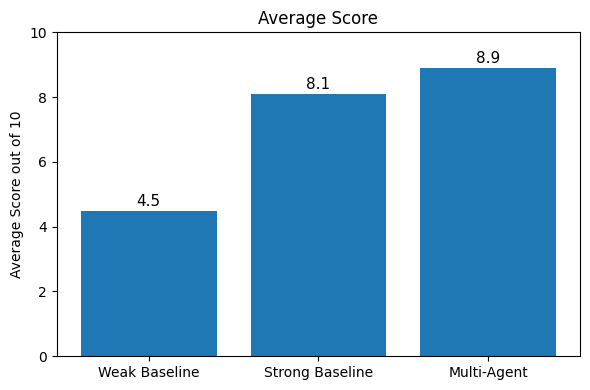

In [ ]:
import matplotlib.pyplot as plt

# Average scores from the three stress-test queries
systems = ["Weak Baseline", "Strong Baseline", "Multi-Agent"]
scores = [4.5, 8.1, 8.9]

plt.figure(figsize=(6, 4))
bars = plt.bar(systems, scores)

# Add value labels on top of bars
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{score:.1f}",
        ha="center",
        fontsize=11
    )

plt.ylim(0, 10)
plt.ylabel("Average Score out of 10")
plt.title("Average Score")
plt.tight_layout()

# Save as image for Overleaf
plt.savefig("average_score_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


def backtest_strategy(
    ticker: str,
    start="2020-01-01",
    end="2025-01-01",
    initial_capital=10000,
    transaction_cost=0.001
):
    df = yf.download(ticker, start=start, end=end, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.dropna(inplace=True)

    LOOKBACK = 50
    signals = []

    for i in range(LOOKBACK, len(df)):
        historical_df = df.iloc[:i].copy()
        indicators = get_technical_indicators(historical_df)
        weighted = get_weighted_signals(indicators)
        score = weighted.get("composite_score", 0)
        if score > 15:
            signal = 1
        else:
            signal = 0

        signals.append(signal)

    df = df.iloc[-len(signals):].copy()
    df["signal"] = signals

    df["position"] = df["signal"].shift(1).fillna(0)

    df["market_return"] = df["Close"].pct_change().fillna(0)
    df["trade"]         = df["position"].diff().abs().fillna(0)
    df["cost"]          = df["trade"] * transaction_cost
    df["strategy_return"] = (
        df["position"] * df["market_return"] - df["cost"]
    ).fillna(0)

    df["portfolio_value"]  = (1 + df["strategy_return"]).cumprod() * initial_capital
    df["buyhold_value"]    = (1 + df["market_return"]).cumprod()   * initial_capital

    def sharpe(returns):
        return (returns.mean() / returns.std() * np.sqrt(252)
                if returns.std() > 0 else 0.0)

    def max_dd(values):
        return (values / values.cummax() - 1).min()

    strat_ret  = df["portfolio_value"].iloc[-1] / initial_capital - 1
    bh_ret     = df["buyhold_value"].iloc[-1]   / initial_capital - 1
    strat_sh   = sharpe(df["strategy_return"])
    bh_sh      = sharpe(df["market_return"])
    strat_dd   = max_dd(df["portfolio_value"])
    bh_dd      = max_dd(df["buyhold_value"])
    n_trades   = int(df["trade"].sum())
    pct_long   = (df["position"] == 1).mean()

    metrics = {
        "ticker":            ticker,
        "strategy_return":   strat_ret,
        "buyhold_return":    bh_ret,
        "strategy_sharpe":   strat_sh,
        "buyhold_sharpe":    bh_sh,
        "strategy_maxdd":    strat_dd,
        "buyhold_maxdd":     bh_dd,
        "n_trades":          n_trades,
        "pct_long":          pct_long,
    }

    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.2%}" if "return" in k or "dd" in k or "pct" in k
                  else f"{k}: {v:.2f}")
        else:
            print(f"{k}: {v}")

    return df, metrics


ticker: NVDA
strategy_return: 28.17%
buyhold_return: 2644.86%
strategy_sharpe: 0.52
buyhold_sharpe: 1.58
strategy_maxdd: -12.07%
buyhold_maxdd: -66.34%
n_trades: 8
pct_long: 3.06%
ticker: TSLA
strategy_return: 0.00%
buyhold_return: 1261.04%
strategy_sharpe: 0.00
buyhold_sharpe: 1.16
strategy_maxdd: 0.00%
buyhold_maxdd: -73.63%
n_trades: 0
pct_long: 0.00%
ticker: COIN
strategy_return: -44.33%
buyhold_return: 7.99%
strategy_sharpe: 0.17
buyhold_sharpe: 0.47
strategy_maxdd: -90.90%
buyhold_maxdd: -90.90%
n_trades: 2
pct_long: 68.96%


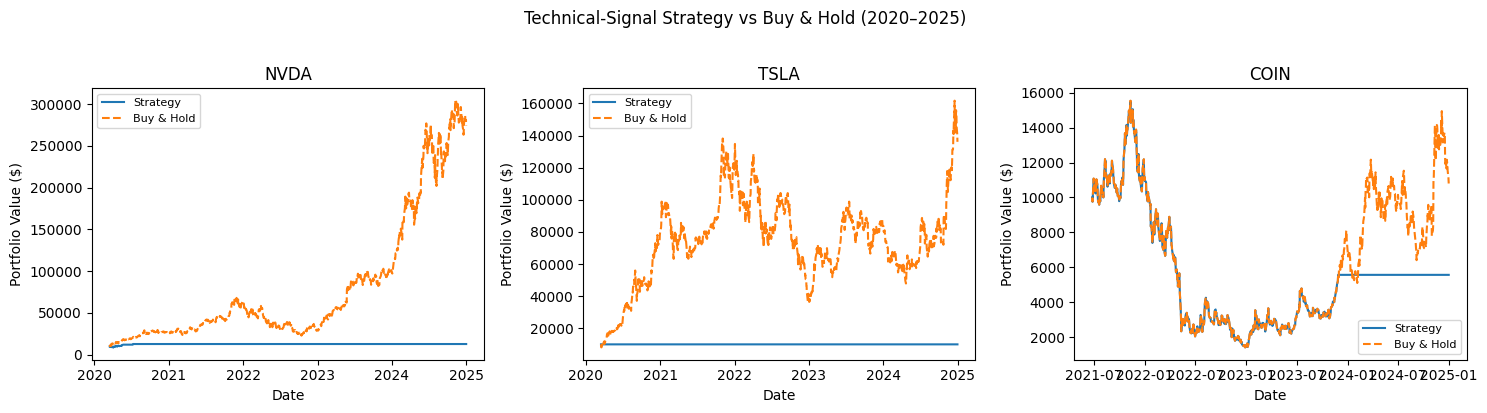

In [ ]:
#Run across tickers
tickers = ["NVDA", "TSLA", "COIN"]
all_metrics = []

fig, axes = plt.subplots(1, len(tickers), figsize=(15, 4), sharey=False)

for ax, ticker in zip(axes, tickers):
    df, m = backtest_strategy(ticker)
    all_metrics.append(m)

    ax.plot(df.index, df["portfolio_value"], label="Strategy")
    ax.plot(df.index, df["buyhold_value"],   label="Buy & Hold", linestyle="--")
    ax.set_title(ticker)
    ax.set_xlabel("Date")
    ax.set_ylabel("Portfolio Value ($)")
    ax.legend(fontsize=8)

plt.suptitle("Technical-Signal Strategy vs Buy & Hold (2020–2025)", y=1.02)
plt.tight_layout()
plt.show()



In [ ]:
#Summary table
summary = pd.DataFrame(all_metrics).set_index("ticker")
summary.columns = [c.replace("_", " ").title() for c in summary.columns]
print("\n", summary.to_string())


         Strategy Return  Buyhold Return  Strategy Sharpe  Buyhold Sharpe  Strategy Maxdd  Buyhold Maxdd  N Trades  Pct Long
ticker                                                                                                                     
NVDA          20.056996       26.448552         1.491114        1.575362       -0.663351      -0.663351         9  0.968543
TSLA          12.596362       12.610443         1.163828        1.164172       -0.736322      -0.736322         1  0.999172
COIN           0.933818        0.079894         0.624482        0.472157       -0.473204      -0.908979         1  0.309255
